# Tree Search: CPU vs OpenACC (GPU) Comparison

Comparing IQ-TREE tree search results across 2 workflows:
- **VANILA** (1 CPU)
- **OPENACC** (GPU V100)

**Data types**: DNA (GTR+R4, 100 taxa) and Amino Acid (LG+I+G4, 100 taxa)  
**Alignment lengths**: 100, 1K, 10K, 100K, 1M, 10M sites  
**Task**: Full tree search (NNI-based ML tree inference)

> **Note**: AA 1M results are in-progress (log files only, no .iqtree yet).  
> AA 10M and DNA 10M directories exist but are empty (runs not yet started).

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display, HTML

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 11

RESULTS_DIR = '/Users/u7826985/Projects/Nvidia/results/2026_03_30_treesearch'
SAVE_DIR = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_30_treesearch'
os.makedirs(SAVE_DIR, exist_ok=True)

wf_labels = {'VANILA': '1 CPU', 'OPENACC': 'GPU (V100)'}
wf_order = ['1 CPU', 'GPU (V100)']
wf_colors = {'1 CPU': '#1f77b4', 'GPU (V100)': '#2ca02c'}

def fmt_time(sec):
    if pd.isna(sec):
        return 'N/A'
    if sec < 60:
        return f'{sec:.1f}s'
    elif sec < 3600:
        return f'{sec/60:.1f}m'
    else:
        return f'{sec/3600:.1f}h'

## 1. Data Loading and Parsing

In [2]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for tree search metrics."""
    data = {}
    try:
        with open(filepath) as f:
            text = f.read()
    except:
        return data
    
    # Log-likelihood
    m = re.search(r'Log-likelihood of the tree:\s+([\-\d.]+)', text)
    if m:
        data['log_likelihood'] = float(m.group(1))
    
    # Tree length
    m = re.search(r'Total tree length.*?:\s+([\d.]+)', text)
    if m:
        data['tree_length'] = float(m.group(1))
    
    # Internal branch length percentage
    m = re.search(r'Sum of internal branch lengths:.*\(([\d.]+)%', text)
    if m:
        data['internal_branch_pct'] = float(m.group(1))
    
    # Wall-clock time
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)\s+seconds', text)
    if m:
        data['wall_time_sec'] = float(m.group(1))
    
    # CPU time
    m = re.search(r'Total CPU time used:\s+([\d.]+)\s+seconds', text)
    if m:
        data['cpu_time_sec'] = float(m.group(1))
    
    # Number of free parameters
    m = re.search(r'Number of free parameters.*?:\s+(\d+)', text)
    if m:
        data['n_params'] = int(m.group(1))
    
    # BIC
    m = re.search(r'Bayesian information criterion.*?:\s+([\d.]+)', text)
    if m:
        data['bic'] = float(m.group(1))
    
    # AIC
    m = re.search(r'Akaike information criterion \(AIC\).*?:\s+([\d.]+)', text)
    if m:
        data['aic'] = float(m.group(1))
    
    return data


def parse_log_file(filepath):
    """Parse .log file for tree search specific metrics."""
    data = {}
    try:
        with open(filepath) as f:
            text = f.read()
    except:
        return data
    
    # Total number of NNI iterations
    m = re.search(r'Total number of iterations:\s+(\d+)', text)
    if m:
        data['nni_iterations'] = int(m.group(1))
    
    # Tree search wall-clock time
    m = re.search(r'Wall-clock time used for tree search:\s+([\d.]+)\s+sec', text)
    if m:
        data['tree_search_wall_sec'] = float(m.group(1))
    
    # Tree search CPU time
    m = re.search(r'CPU time used for tree search:\s+([\d.]+)\s+sec', text)
    if m:
        data['tree_search_cpu_sec'] = float(m.group(1))
    
    # Best score found
    m = re.search(r'BEST SCORE FOUND\s*:\s+([\-\d.]+)', text)
    if m:
        data['best_score'] = float(m.group(1))
    
    # Number of candidate trees
    m = re.search(r'Finish initializing candidate tree set \((\d+)\)', text)
    if m:
        data['n_candidate_trees'] = int(m.group(1))
    
    # Initial tree computation time
    m = re.search(r'Computing log-likelihood of 98 initial trees.*?([\d.]+)\s+seconds', text)
    if m:
        data['initial_trees_sec'] = float(m.group(1))
    
    # Parsimony tree generation time
    m = re.search(r'Generating 98 parsimony trees.*?([\d.]+)\s+second', text)
    if m:
        data['parsimony_gen_sec'] = float(m.group(1))
    
    # TREE SEARCH COMPLETED check
    data['completed'] = 'TREE SEARCH COMPLETED' in text or 'FINALIZING TREE SEARCH' in text
    
    # For in-progress runs: extract last iteration info
    iterations = re.findall(r'Iteration (\d+) / LogL: ([\-\d.]+) / Time: (.+)', text)
    if iterations:
        last_iter = iterations[-1]
        data['last_iteration'] = int(last_iter[0])
        data['last_lnl'] = float(last_iter[1])
        data['last_time_str'] = last_iter[2].strip()
    
    # Extract current best tree score from candidate set
    m = re.search(r'Current best tree score:\s+([\-\d.]+)\s*/\s*CPU time:\s+([\d.]+)', text)
    if m:
        data['best_candidate_score'] = float(m.group(1))
        data['candidate_cpu_time'] = float(m.group(2))
    
    return data


# Discover and parse all results
rows = []
seen = set()  # track (data_type, length, workflow) to avoid duplicates

for data_type in ['DNA', 'AA']:
    type_dir = os.path.join(RESULTS_DIR, data_type)
    if not os.path.isdir(type_dir):
        continue
    for len_dir in sorted(glob.glob(os.path.join(type_dir, 'len_*'))):
        length = int(os.path.basename(len_dir).replace('len_', ''))
        
        # First pass: discover from .iqtree files (completed runs)
        for iqtree_file in glob.glob(os.path.join(len_dir, '*.iqtree')):
            fname = os.path.basename(iqtree_file)
            if '_OPENACC_' in fname:
                wf = 'OPENACC'
            elif '_VANILA_' in fname:
                wf = 'VANILA'
            else:
                continue
            
            row = parse_iqtree_file(iqtree_file)
            log_file = iqtree_file.replace('.iqtree', '.log')
            if os.path.exists(log_file):
                row.update(parse_log_file(log_file))
            
            row['data_type'] = data_type
            row['length'] = length
            row['workflow'] = wf
            row['workflow_label'] = wf_labels.get(wf, wf)
            row['status'] = 'completed'
            rows.append(row)
            seen.add((data_type, length, wf))
        
        # Second pass: discover from .log files (in-progress runs without .iqtree)
        for log_file in glob.glob(os.path.join(len_dir, '*.log')):
            fname = os.path.basename(log_file)
            if '_OPENACC_' in fname:
                wf = 'OPENACC'
            elif '_VANILA_' in fname:
                wf = 'VANILA'
            else:
                continue
            
            if (data_type, length, wf) in seen:
                continue  # already parsed from .iqtree
            
            row = parse_log_file(log_file)
            row['data_type'] = data_type
            row['length'] = length
            row['workflow'] = wf
            row['workflow_label'] = wf_labels.get(wf, wf)
            row['status'] = 'in-progress'
            rows.append(row)
            seen.add((data_type, length, wf))

df_all = pd.DataFrame(rows)
df_all = df_all.sort_values(['data_type', 'length', 'workflow']).reset_index(drop=True)

df_completed = df_all[df_all['status'] == 'completed'].copy()
df_inprogress = df_all[df_all['status'] == 'in-progress'].copy()

df_dna = df_completed[df_completed['data_type'] == 'DNA'].copy()
df_aa = df_completed[df_completed['data_type'] == 'AA'].copy()

print(f'Total results parsed: {len(df_all)} ({len(df_completed)} completed, {len(df_inprogress)} in-progress)')
print(f'DNA completed: {len(df_dna)} — lengths: {sorted(df_dna["length"].unique())}')
print(f'AA completed: {len(df_aa)} — lengths: {sorted(df_aa["length"].unique())}')
print(f'Workflows: {sorted(df_all["workflow"].unique())}')

if len(df_inprogress) > 0:
    print(f'\nIn-progress runs:')
    for _, r in df_inprogress.iterrows():
        last_iter = r.get('last_iteration', '?')
        last_lnl = f"{r['last_lnl']:,.4f}" if pd.notna(r.get('last_lnl')) else '?'
        last_time = r.get('last_time_str', '?')
        init_sec = f"{r['initial_trees_sec']:,.1f}s" if pd.notna(r.get('initial_trees_sec')) else 'N/A'
        print(f"  {r['data_type']} len={r['length']:,} {r['workflow_label']}: "
              f"iter {last_iter}, lnL={last_lnl}, elapsed~{last_time}, init_trees={init_sec}")


Total results parsed: 20 (18 completed, 2 in-progress)
DNA completed: 10 — lengths: [100, 1000, 10000, 100000, 1000000]
AA completed: 8 — lengths: [100, 1000, 10000, 100000]
Workflows: ['OPENACC', 'VANILA']

In-progress runs:
  AA len=1,000,000 GPU (V100): iter 10, lnL=-83,153,182.4420, elapsed~3h:18m:35s, init_trees=739.4s
  AA len=1,000,000 1 CPU: iter 90, lnL=-83,153,242.6510, elapsed~45h:40m:35s (5h:38m:23s left), init_trees=10,271.8s


In [3]:
# Display full summary table
display_cols = ['data_type', 'length', 'workflow_label', 'status', 'log_likelihood', 'tree_length',
                'nni_iterations', 'tree_search_wall_sec', 'wall_time_sec', 'cpu_time_sec',
                'initial_trees_sec', 'n_candidate_trees', 'completed']
available_cols = [c for c in display_cols if c in df_all.columns]
display(df_all[available_cols].style.format({
    'log_likelihood': '{:,.4f}',
    'tree_length': '{:.4f}',
    'tree_search_wall_sec': '{:,.1f}',
    'wall_time_sec': '{:,.1f}',
    'cpu_time_sec': '{:,.1f}',
    'initial_trees_sec': '{:,.1f}',
}, na_rep='N/A'))

,data_type,length,workflow_label,status,log_likelihood,tree_length,nni_iterations,tree_search_wall_sec,wall_time_sec,cpu_time_sec,initial_trees_sec,n_candidate_trees,completed
0,AA,100,GPU (V100),completed,"-8,152.4255",17.0624,103.000000,260.1,261.1,261.1,11.3,4.000000,True
1,AA,100,1 CPU,completed,"-8,152.4255",17.0624,103.000000,23.4,24.0,23.5,1.1,4.000000,True
2,AA,1000,GPU (V100),completed,"-82,228.9392",17.4011,102.000000,248.8,249.8,249.7,12.7,1.000000,True
3,AA,1000,1 CPU,completed,"-82,228.9392",17.4011,102.000000,158.3,159.3,158.0,8.7,1.000000,True
4,AA,10000,GPU (V100),completed,"-854,126.3618",18.4702,102.000000,399.3,401.2,401.2,18.3,1.000000,True
5,AA,10000,1 CPU,completed,"-854,126.3618",18.4702,102.000000,"1,578.8","1,588.7","1,587.3",86.1,1.000000,True
6,AA,100000,GPU (V100),completed,"-7,964,675.1129",16.4933,102.000000,"2,160.1","2,172.3","2,165.7",86.8,1.000000,True
7,AA,100000,1 CPU,completed,"-7,964,675.1129",16.4933,102.000000,"16,511.1","16,611.1","16,397.7",970.0,1.000000,True
8,AA,1000000,GPU (V100),in-progress,N/A,N/A,N/A,N/A,N/A,N/A,739.4,N/A,False
9,AA,1000000,1 CPU,in-progress,N/A,N/A,N/A,N/A,N/A,N/A,"10,271.8",2.000000,False


---
# Part 1: DNA Analysis (GTR+R4)

## 2. Log-Likelihood Agreement (DNA)

Check if CPU and GPU find the same (or very close) optimal tree.

In [4]:
df = df_dna.copy()

lnl_pivot = df.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
lnl_pivot = lnl_pivot[[c for c in wf_order if c in lnl_pivot.columns]]

print('Log-likelihood values (DNA):')
print(lnl_pivot.to_string(float_format='%.4f'))
print()

# Compute difference
if '1 CPU' in lnl_pivot.columns and 'GPU (V100)' in lnl_pivot.columns:
    lnl_pivot['|Diff|'] = (lnl_pivot['1 CPU'] - lnl_pivot['GPU (V100)']).abs()
    lnl_pivot['Match'] = lnl_pivot['|Diff|'].apply(lambda x: 'EXACT' if x < 1e-4 else ('CLOSE' if x < 1.0 else 'DIFFER'))
    print('CPU vs GPU log-likelihood difference (DNA):')
    print(lnl_pivot[['|Diff|', 'Match']].to_string(float_format='%.6f'))

Log-likelihood values (DNA):
workflow_label          1 CPU     GPU (V100)
length                                      
100                -6468.0771     -6467.8695
1000              -59378.2131    -59378.2131
10000            -662309.6978   -662309.6978
100000          -6170656.8687  -6170656.8687
1000000        -60624916.7486 -60624916.7486

CPU vs GPU log-likelihood difference (DNA):
workflow_label   |Diff|  Match
length                        
100            0.207600  CLOSE
1000           0.000000  EXACT
10000          0.000000  EXACT
100000         0.000000  EXACT
1000000        0.000000  EXACT


### Log-Likelihood Comparison Heatmap (DNA)

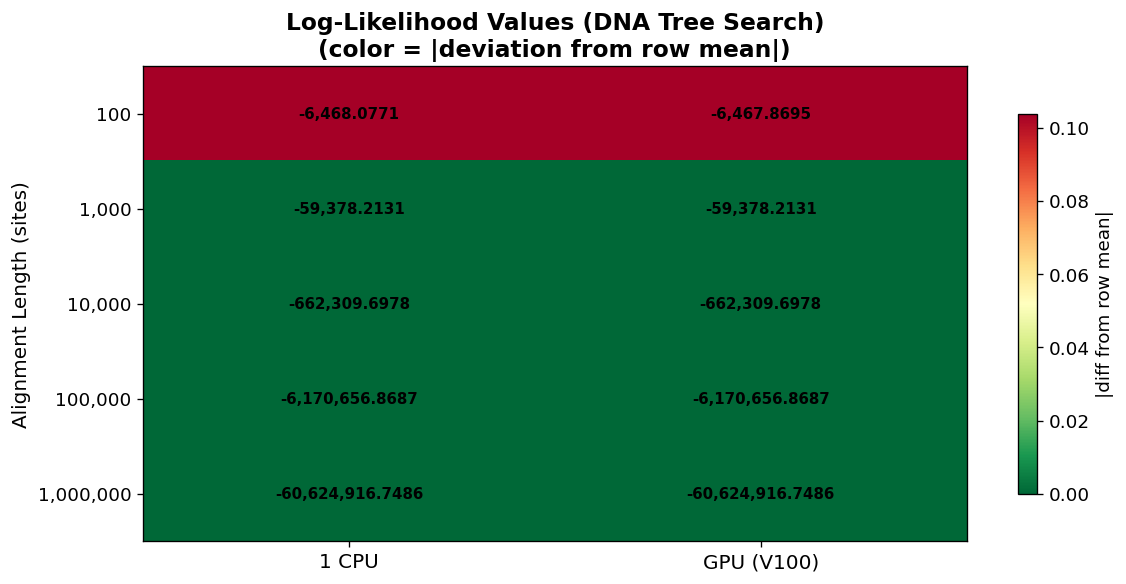

In [5]:
df = df_dna.copy()

lnl_pivot_full = df.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
lnl_cols = [c for c in wf_order if c in lnl_pivot_full.columns]
lnl_pivot_full = lnl_pivot_full[lnl_cols]

row_means = lnl_pivot_full.mean(axis=1)
lnl_diff_from_mean = lnl_pivot_full.sub(row_means, axis=0).abs()

max_diff = lnl_diff_from_mean.max().max()
if pd.isna(max_diff) or max_diff == 0:
    max_diff = 1.0
norm = mcolors.Normalize(vmin=0, vmax=max_diff)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(lnl_diff_from_mean.fillna(0).values, cmap='RdYlGn_r', aspect='auto', norm=norm)
ax.set_xticks(range(len(lnl_cols)))
ax.set_xticklabels(lnl_cols, fontsize=12)
ax.set_yticks(range(len(lnl_pivot_full.index)))
ax.set_yticklabels([f'{l:,}' for l in lnl_pivot_full.index], fontsize=11)
ax.set_ylabel('Alignment Length (sites)', fontsize=12)
ax.set_title('Log-Likelihood Values (DNA Tree Search)\n(color = |deviation from row mean|)', fontsize=14, fontweight='bold')

for i in range(len(lnl_pivot_full.index)):
    for j in range(len(lnl_cols)):
        val = lnl_pivot_full.iloc[i, j]
        if pd.notna(val):
            txt = f'{val:,.4f}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9, fontweight='bold')
        else:
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=9, color='gray')

plt.colorbar(im, ax=ax, label='|diff from row mean|', shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'lnl_heatmap_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. NNI Iterations & Candidate Trees (DNA)

In [6]:
df = df_dna.copy()

nni_pivot = df.pivot_table(index='length', columns='workflow_label', values='nni_iterations', aggfunc='first')
nni_pivot = nni_pivot[[c for c in wf_order if c in nni_pivot.columns]]

cand_pivot = df.pivot_table(index='length', columns='workflow_label', values='n_candidate_trees', aggfunc='first')
cand_pivot = cand_pivot[[c for c in wf_order if c in cand_pivot.columns]]

print('NNI iterations (DNA):')
print(nni_pivot.to_string())
print()
print('Candidate trees found (DNA):')
print(cand_pivot.to_string())

if '1 CPU' in nni_pivot.columns and 'GPU (V100)' in nni_pivot.columns:
    nni_pivot['Match'] = nni_pivot.apply(lambda r: 'YES' if r['1 CPU'] == r['GPU (V100)'] else 'NO', axis=1)
    print()
    print('NNI iteration match (CPU == GPU)?')
    print(nni_pivot[['Match']].to_string())

NNI iterations (DNA):
workflow_label  1 CPU  GPU (V100)
length                           
100             166.0       149.0
1000            103.0       104.0
10000           102.0       102.0
100000          102.0       102.0
1000000         102.0       102.0

Candidate trees found (DNA):
workflow_label  1 CPU  GPU (V100)
length                           
100              17.0        20.0
1000              8.0         4.0
10000             1.0         1.0
100000            3.0         2.0
1000000           4.0         1.0

NNI iteration match (CPU == GPU)?
workflow_label Match
length              
100               NO
1000              NO
10000            YES
100000           YES
1000000          YES


## 4. Tree Length & Topology Comparison (DNA)

In [7]:
df = df_dna.copy()

tl_pivot = df.pivot_table(index='length', columns='workflow_label', values='tree_length', aggfunc='first')
tl_pivot = tl_pivot[[c for c in wf_order if c in tl_pivot.columns]]

print('Tree length (DNA):')
print(tl_pivot.to_string(float_format='%.4f'))

if '1 CPU' in tl_pivot.columns and 'GPU (V100)' in tl_pivot.columns:
    tl_pivot['|Diff|'] = (tl_pivot['1 CPU'] - tl_pivot['GPU (V100)']).abs()
    print()
    print('Tree length difference:')
    print(tl_pivot[['|Diff|']].to_string(float_format='%.6f'))

# Internal branch percentage
ib_pivot = df.pivot_table(index='length', columns='workflow_label', values='internal_branch_pct', aggfunc='first')
ib_pivot = ib_pivot[[c for c in wf_order if c in ib_pivot.columns]]
print()
print('Internal branch length % (DNA):')
print(ib_pivot.to_string(float_format='%.4f'))

Tree length (DNA):
workflow_label   1 CPU  GPU (V100)
length                            
100            18.3148     18.3445
1000           15.3945     15.3945
10000          18.6946     18.6946
100000         17.5716     17.5716
1000000        16.8133     16.8133

Tree length difference:
workflow_label   |Diff|
length                 
100            0.029700
1000           0.000000
10000          0.000000
100000         0.000000
1000000        0.000000

Internal branch length % (DNA):
workflow_label   1 CPU  GPU (V100)
length                            
100            49.5171     49.6810
1000           46.2271     46.2272
10000          48.4010     48.4010
100000         50.1298     50.1298
1000000        44.3271     44.3271


## 5. Wall-Clock Runtime Comparison (DNA)

In [8]:
time_pivot_dna = df_dna.pivot_table(index='length', columns='workflow_label', values='wall_time_sec', aggfunc='first')
time_pivot_dna = time_pivot_dna[[c for c in wf_order if c in time_pivot_dna.columns]]

print('Wall-clock time (seconds) - DNA:')
print(time_pivot_dna.to_string(float_format='%.1f'))
print()
print('Wall-clock time (human-readable) - DNA:')
print(time_pivot_dna.applymap(fmt_time).to_string())

Wall-clock time (seconds) - DNA:
workflow_label   1 CPU  GPU (V100)
length                            
100                7.8       335.0
1000              16.4       194.3
10000            154.5       234.3
100000          1790.6       642.6
1000000        23104.1      5097.9

Wall-clock time (human-readable) - DNA:
workflow_label  1 CPU GPU (V100)
length                          
100              7.8s       5.6m
1000            16.4s       3.2m
10000            2.6m       3.9m
100000          29.8m      10.7m
1000000          6.4h       1.4h


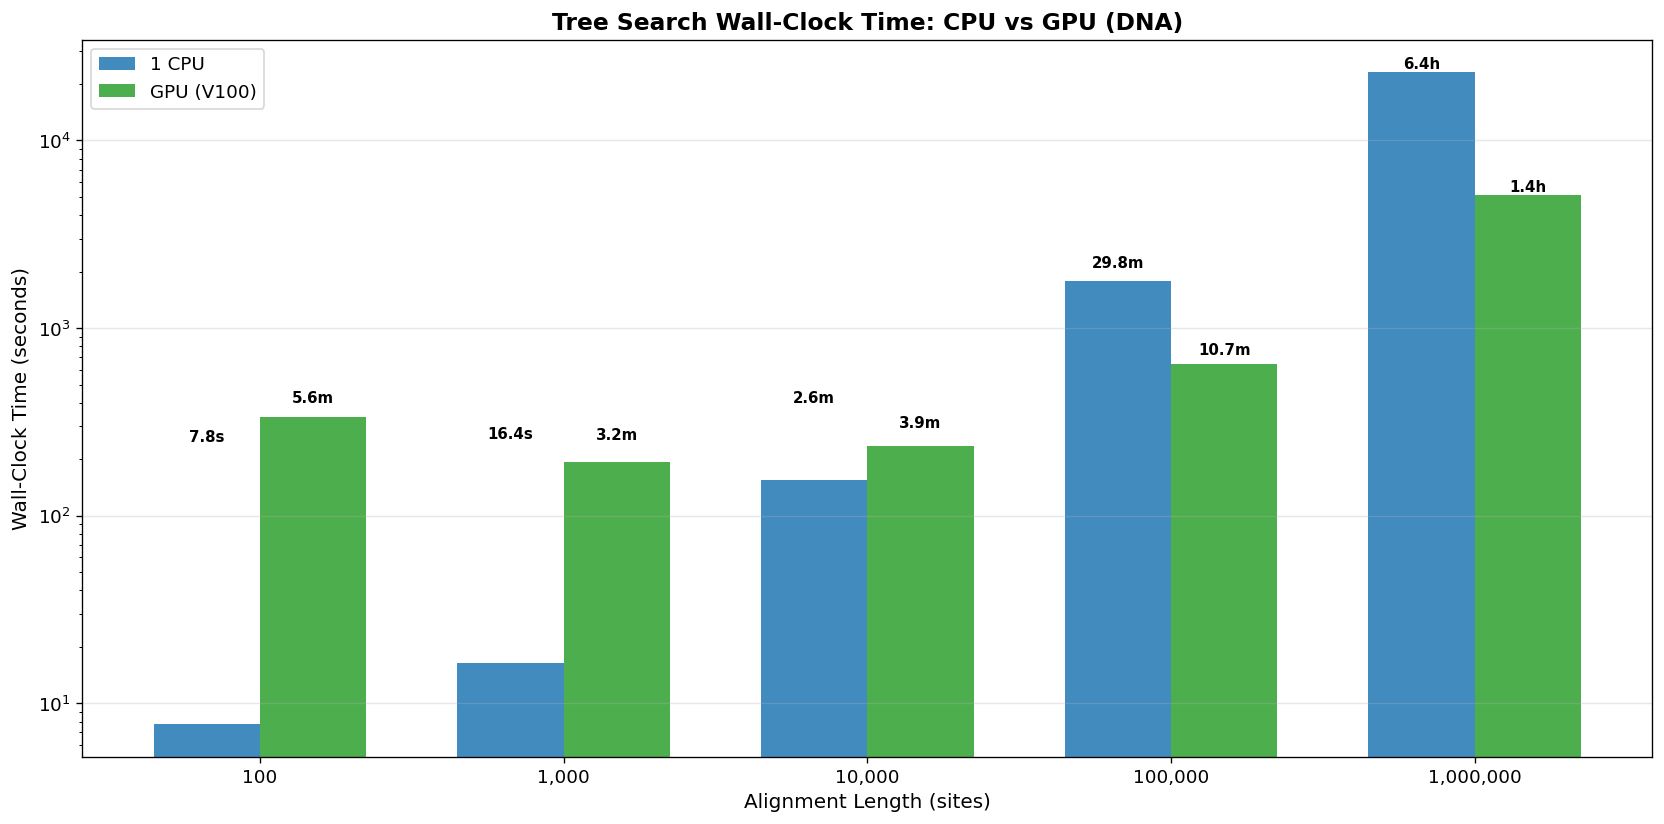

In [9]:
# Wall-clock time bar chart (DNA)
fig, ax = plt.subplots(figsize=(14, 7))

available_wfs = [c for c in wf_order if c in time_pivot_dna.columns]
valid_lengths = time_pivot_dna.dropna(thresh=1).index
x = np.arange(len(valid_lengths))
width = 0.35
n_wf = len(available_wfs)

for i, wf in enumerate(available_wfs):
    vals = [time_pivot_dna.loc[l, wf] if l in time_pivot_dna.index and pd.notna(time_pivot_dna.loc[l, wf]) else 0 
            for l in valid_lengths]
    offset = (i - (n_wf-1)/2) * width
    bars = ax.bar(x + offset, vals, width, label=wf, color=wf_colors.get(wf, None), alpha=0.85)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                    fmt_time(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{l:,}' for l in valid_lengths], fontsize=11)
ax.set_xlabel('Alignment Length (sites)', fontsize=12)
ax.set_ylabel('Wall-Clock Time (seconds)', fontsize=12)
ax.set_title('Tree Search Wall-Clock Time: CPU vs GPU (DNA)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_comparison_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Speedup Analysis (DNA)

In [10]:
if '1 CPU' in time_pivot_dna.columns and 'GPU (V100)' in time_pivot_dna.columns:
    speedup_dna = time_pivot_dna['1 CPU'] / time_pivot_dna['GPU (V100)']
    speedup_dna_df = pd.DataFrame({'Speedup (CPU/GPU)': speedup_dna})
    print('GPU Speedup over 1 CPU (DNA):')
    print(speedup_dna_df.to_string(float_format='%.2f'))
    print()
    print(f'GPU is FASTER when speedup > 1.0')
    print(f'GPU is SLOWER when speedup < 1.0')
    
    # Also show tree-search-only speedup
    ts_pivot_dna = df_dna.pivot_table(index='length', columns='workflow_label', values='tree_search_wall_sec', aggfunc='first')
    if '1 CPU' in ts_pivot_dna.columns and 'GPU (V100)' in ts_pivot_dna.columns:
        ts_speedup = ts_pivot_dna['1 CPU'] / ts_pivot_dna['GPU (V100)']
        speedup_dna_df['Tree Search Speedup'] = ts_speedup
        print()
        print('Tree-search-only speedup (DNA):')
        print(speedup_dna_df[['Tree Search Speedup']].to_string(float_format='%.2f'))

GPU Speedup over 1 CPU (DNA):
         Speedup (CPU/GPU)
length                    
100                   0.02
1000                  0.08
10000                 0.66
100000                2.79
1000000               4.53

GPU is FASTER when speedup > 1.0
GPU is SLOWER when speedup < 1.0

Tree-search-only speedup (DNA):
         Tree Search Speedup
length                      
100                     0.02
1000                    0.08
10000                   0.66
100000                  2.79
1000000                 4.55


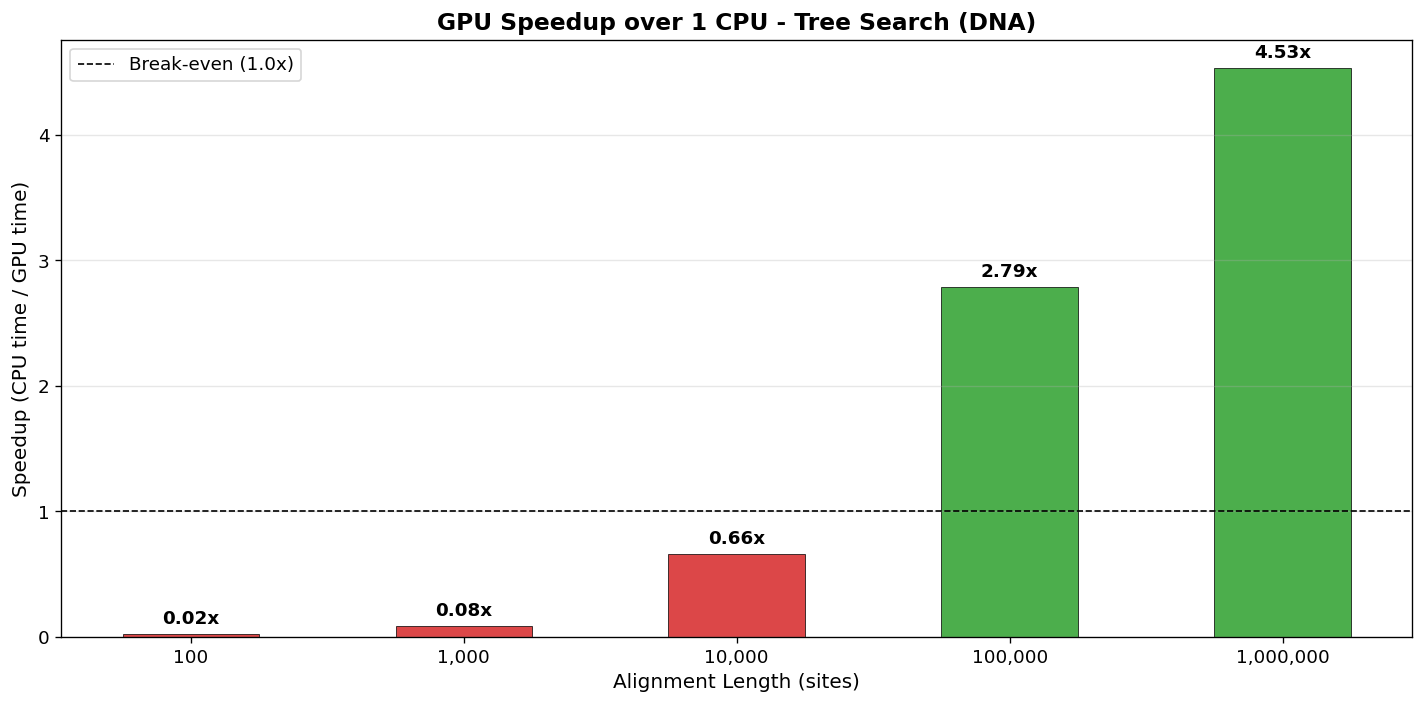

In [11]:
# Speedup bar chart (DNA)
if '1 CPU' in time_pivot_dna.columns and 'GPU (V100)' in time_pivot_dna.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    valid = speedup_dna.dropna()
    x = np.arange(len(valid))
    colors = ['#2ca02c' if v >= 1.0 else '#d62728' for v in valid.values]
    
    bars = ax.bar(x, valid.values, 0.5, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Break-even (1.0x)')
    
    for bar, val in zip(bars, valid.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}x', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in valid.index], fontsize=11)
    ax.set_xlabel('Alignment Length (sites)', fontsize=12)
    ax.set_ylabel('Speedup (CPU time / GPU time)', fontsize=12)
    ax.set_title('GPU Speedup over 1 CPU - Tree Search (DNA)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'speedup_DNA.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 7. Time Breakdown: Initial Trees vs NNI Search (DNA)

Initial tree evaluation time (seconds) - DNA:
workflow_label  1 CPU  GPU (V100)
length                           
100               0.3         9.7
1000              0.9         8.5
10000             9.8         9.7
100000          156.1        22.5
1000000        2038.3       160.3

Tree search time (seconds) - DNA:
workflow_label   1 CPU  GPU (V100)
length                            
100                7.7       334.1
1000              16.2       193.6
10000            153.3       233.0
100000          1774.0       636.1
1000000        22896.7      5034.6


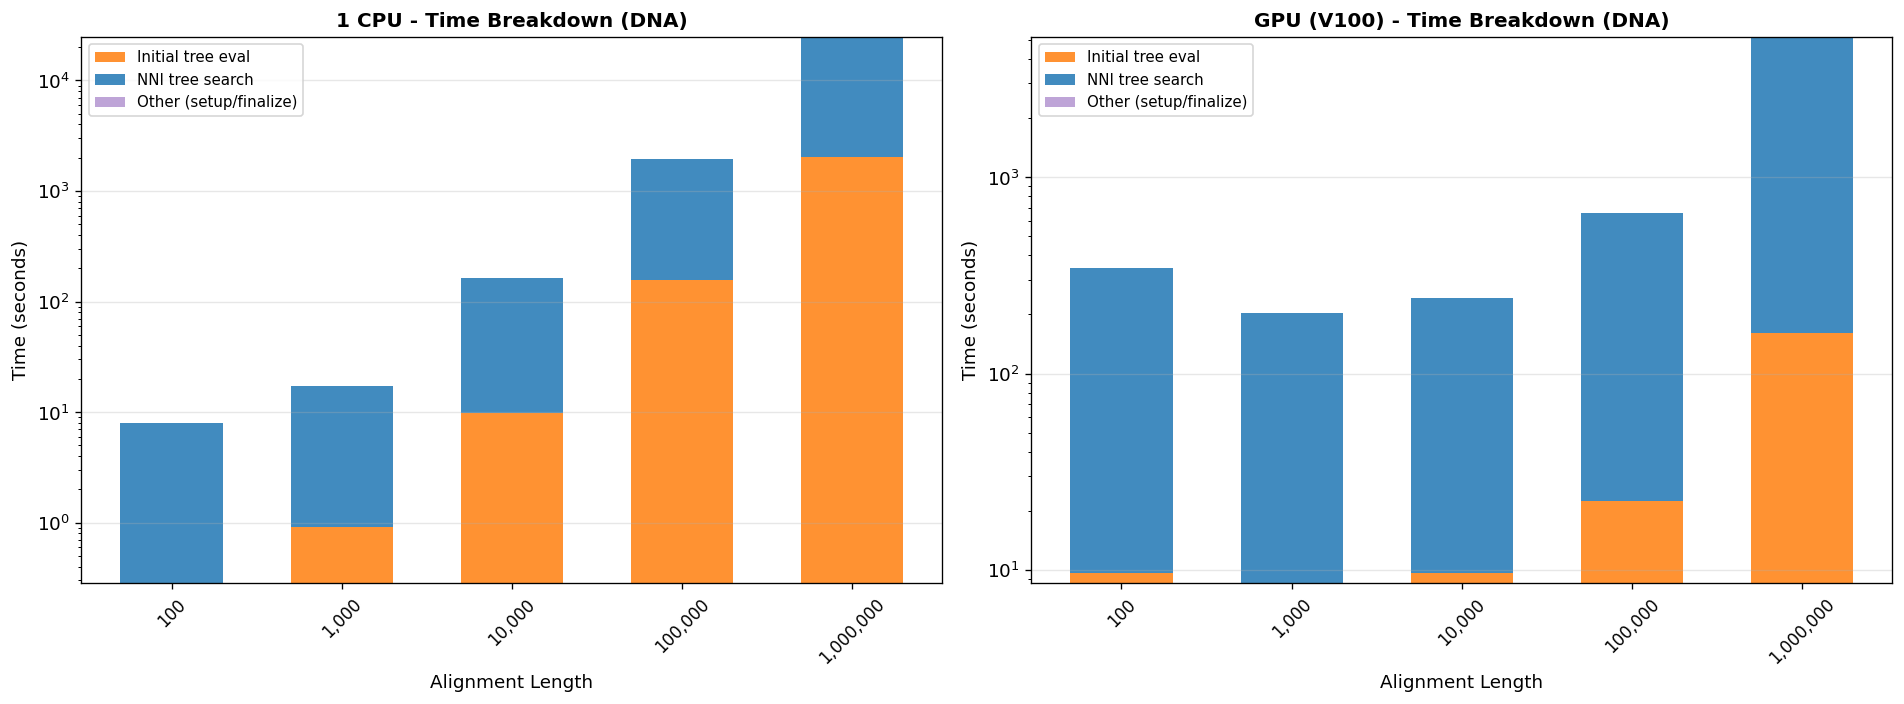

In [12]:
df = df_dna.copy()

# Initial tree evaluation time
init_pivot = df.pivot_table(index='length', columns='workflow_label', values='initial_trees_sec', aggfunc='first')
init_pivot = init_pivot[[c for c in wf_order if c in init_pivot.columns]]

# Tree search time
ts_pivot = df.pivot_table(index='length', columns='workflow_label', values='tree_search_wall_sec', aggfunc='first')
ts_pivot = ts_pivot[[c for c in wf_order if c in ts_pivot.columns]]

print('Initial tree evaluation time (seconds) - DNA:')
print(init_pivot.to_string(float_format='%.1f'))
print()
print('Tree search time (seconds) - DNA:')
print(ts_pivot.to_string(float_format='%.1f'))

# Stacked bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, wf in enumerate(available_wfs):
    if wf not in init_pivot.columns or wf not in ts_pivot.columns:
        continue
    ax = axes[idx]
    lengths = init_pivot.index
    init_vals = [init_pivot.loc[l, wf] if pd.notna(init_pivot.loc[l, wf]) else 0 for l in lengths]
    ts_vals = [ts_pivot.loc[l, wf] if pd.notna(ts_pivot.loc[l, wf]) else 0 for l in lengths]
    # Other time = total - init - ts
    total_vals = [time_pivot_dna.loc[l, wf] if pd.notna(time_pivot_dna.loc[l, wf]) else 0 for l in lengths]
    other_vals = [max(0, t - i - s) for t, i, s in zip(total_vals, init_vals, ts_vals)]
    
    x = np.arange(len(lengths))
    ax.bar(x, init_vals, 0.6, label='Initial tree eval', color='#ff7f0e', alpha=0.85)
    ax.bar(x, ts_vals, 0.6, bottom=init_vals, label='NNI tree search', color='#1f77b4', alpha=0.85)
    bottom2 = [i + s for i, s in zip(init_vals, ts_vals)]
    ax.bar(x, other_vals, 0.6, bottom=bottom2, label='Other (setup/finalize)', color='#9467bd', alpha=0.6)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in lengths], fontsize=10, rotation=45)
    ax.set_xlabel('Alignment Length', fontsize=11)
    ax.set_ylabel('Time (seconds)', fontsize=11)
    ax.set_title(f'{wf} - Time Breakdown (DNA)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'time_breakdown_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary: GPU vs CPU (DNA)

In [13]:
if '1 CPU' in time_pivot_dna.columns and 'GPU (V100)' in time_pivot_dna.columns:
    summary_rows = []
    for length in time_pivot_dna.index:
        cpu_time = time_pivot_dna.loc[length, '1 CPU']
        gpu_time = time_pivot_dna.loc[length, 'GPU (V100)']
        cpu_lnl = lnl_pivot.loc[length, '1 CPU'] if length in lnl_pivot.index else None
        gpu_lnl = lnl_pivot.loc[length, 'GPU (V100)'] if length in lnl_pivot.index else None
        
        row = {
            'Length': f'{length:,}',
            'CPU Time': fmt_time(cpu_time),
            'GPU Time': fmt_time(gpu_time),
            'Speedup': f'{cpu_time/gpu_time:.2f}x' if pd.notna(cpu_time) and pd.notna(gpu_time) and gpu_time > 0 else 'N/A',
            'CPU lnL': f'{cpu_lnl:,.4f}' if pd.notna(cpu_lnl) else 'N/A',
            'GPU lnL': f'{gpu_lnl:,.4f}' if pd.notna(gpu_lnl) else 'N/A',
            '|lnL Diff|': f'{abs(cpu_lnl - gpu_lnl):.6f}' if pd.notna(cpu_lnl) and pd.notna(gpu_lnl) else 'N/A',
        }
        summary_rows.append(row)
    
    summary_df = pd.DataFrame(summary_rows)
    print('=== DNA Tree Search Summary: GPU vs 1 CPU ===')
    print(summary_df.to_string(index=False))

=== DNA Tree Search Summary: GPU vs 1 CPU ===
   Length CPU Time GPU Time Speedup          CPU lnL          GPU lnL |lnL Diff|
      100     7.8s     5.6m   0.02x      -6,468.0771      -6,467.8695   0.207600
    1,000    16.4s     3.2m   0.08x     -59,378.2131     -59,378.2131   0.000000
   10,000     2.6m     3.9m   0.66x    -662,309.6978    -662,309.6978   0.000000
  100,000    29.8m    10.7m   2.79x  -6,170,656.8687  -6,170,656.8687   0.000000
1,000,000     6.4h     1.4h   4.53x -60,624,916.7486 -60,624,916.7486   0.000000


---
# Part 2: Amino Acid Analysis (LG+I+G4)

## 9. Log-Likelihood Agreement (AA)

In [14]:
df = df_aa.copy()

lnl_pivot_aa = df.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
lnl_pivot_aa = lnl_pivot_aa[[c for c in wf_order if c in lnl_pivot_aa.columns]]

print('Log-likelihood values (AA):')
print(lnl_pivot_aa.to_string(float_format='%.4f'))
print()

if '1 CPU' in lnl_pivot_aa.columns and 'GPU (V100)' in lnl_pivot_aa.columns:
    lnl_pivot_aa['|Diff|'] = (lnl_pivot_aa['1 CPU'] - lnl_pivot_aa['GPU (V100)']).abs()
    lnl_pivot_aa['Match'] = lnl_pivot_aa['|Diff|'].apply(lambda x: 'EXACT' if x < 1e-4 else ('CLOSE' if x < 1.0 else 'DIFFER'))
    print('CPU vs GPU log-likelihood difference (AA):')
    print(lnl_pivot_aa[['|Diff|', 'Match']].to_string(float_format='%.6f'))

Log-likelihood values (AA):
workflow_label         1 CPU    GPU (V100)
length                                    
100               -8152.4255    -8152.4255
1000             -82228.9392   -82228.9392
10000           -854126.3618  -854126.3618
100000         -7964675.1129 -7964675.1129

CPU vs GPU log-likelihood difference (AA):
workflow_label   |Diff|  Match
length                        
100            0.000000  EXACT
1000           0.000000  EXACT
10000          0.000000  EXACT
100000         0.000000  EXACT


### Log-Likelihood Comparison Heatmap (AA)

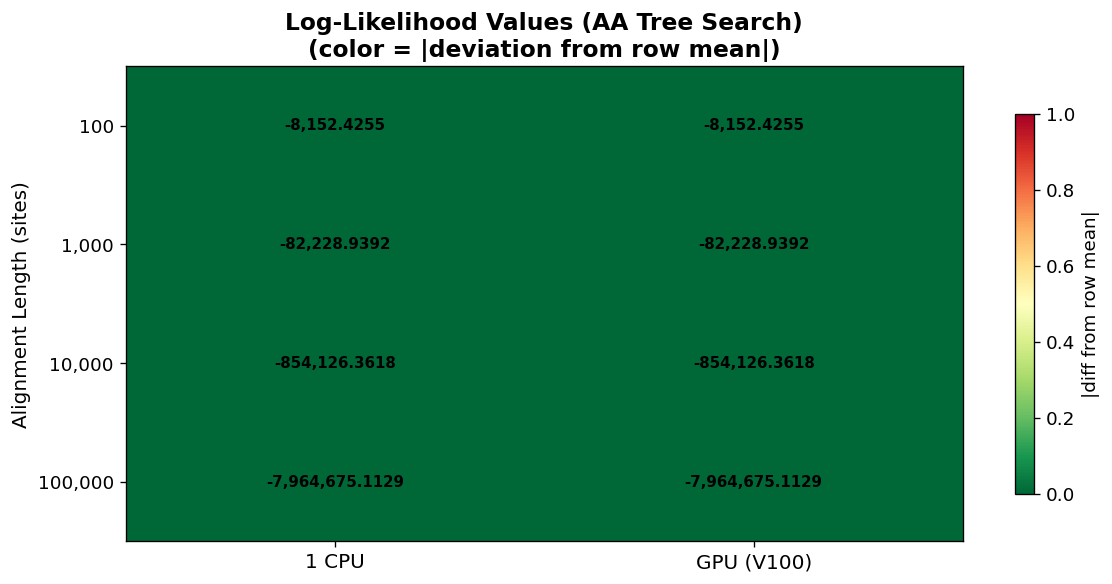

In [15]:
df = df_aa.copy()

lnl_pivot_aa_full = df.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
lnl_aa_cols = [c for c in wf_order if c in lnl_pivot_aa_full.columns]
lnl_pivot_aa_full = lnl_pivot_aa_full[lnl_aa_cols]

row_means = lnl_pivot_aa_full.mean(axis=1)
lnl_diff_from_mean = lnl_pivot_aa_full.sub(row_means, axis=0).abs()

max_diff = lnl_diff_from_mean.max().max()
if pd.isna(max_diff) or max_diff == 0:
    max_diff = 1.0
norm = mcolors.Normalize(vmin=0, vmax=max_diff)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(lnl_diff_from_mean.fillna(0).values, cmap='RdYlGn_r', aspect='auto', norm=norm)
ax.set_xticks(range(len(lnl_aa_cols)))
ax.set_xticklabels(lnl_aa_cols, fontsize=12)
ax.set_yticks(range(len(lnl_pivot_aa_full.index)))
ax.set_yticklabels([f'{l:,}' for l in lnl_pivot_aa_full.index], fontsize=11)
ax.set_ylabel('Alignment Length (sites)', fontsize=12)
ax.set_title('Log-Likelihood Values (AA Tree Search)\n(color = |deviation from row mean|)', fontsize=14, fontweight='bold')

for i in range(len(lnl_pivot_aa_full.index)):
    for j in range(len(lnl_aa_cols)):
        val = lnl_pivot_aa_full.iloc[i, j]
        if pd.notna(val):
            txt = f'{val:,.4f}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9, fontweight='bold')
        else:
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=9, color='gray')

plt.colorbar(im, ax=ax, label='|diff from row mean|', shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'lnl_heatmap_AA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. NNI Iterations & Candidate Trees (AA)

In [16]:
df = df_aa.copy()

nni_pivot_aa = df.pivot_table(index='length', columns='workflow_label', values='nni_iterations', aggfunc='first')
nni_pivot_aa = nni_pivot_aa[[c for c in wf_order if c in nni_pivot_aa.columns]]

cand_pivot_aa = df.pivot_table(index='length', columns='workflow_label', values='n_candidate_trees', aggfunc='first')
cand_pivot_aa = cand_pivot_aa[[c for c in wf_order if c in cand_pivot_aa.columns]]

print('NNI iterations (AA):')
print(nni_pivot_aa.to_string())
print()
print('Candidate trees found (AA):')
print(cand_pivot_aa.to_string())

if '1 CPU' in nni_pivot_aa.columns and 'GPU (V100)' in nni_pivot_aa.columns:
    nni_pivot_aa['Match'] = nni_pivot_aa.apply(
        lambda r: 'YES' if pd.notna(r['1 CPU']) and pd.notna(r['GPU (V100)']) and r['1 CPU'] == r['GPU (V100)'] else 'N/A', axis=1)
    print()
    print('NNI iteration match (CPU == GPU)?')
    print(nni_pivot_aa[['Match']].to_string())

NNI iterations (AA):
workflow_label  1 CPU  GPU (V100)
length                           
100             103.0       103.0
1000            102.0       102.0
10000           102.0       102.0
100000          102.0       102.0

Candidate trees found (AA):
workflow_label  1 CPU  GPU (V100)
length                           
100               4.0         4.0
1000              1.0         1.0
10000             1.0         1.0
100000            1.0         1.0

NNI iteration match (CPU == GPU)?
workflow_label Match
length              
100              YES
1000             YES
10000            YES
100000           YES


## 11. Tree Length & Topology Comparison (AA)

In [17]:
df = df_aa.copy()

tl_pivot_aa = df.pivot_table(index='length', columns='workflow_label', values='tree_length', aggfunc='first')
tl_pivot_aa = tl_pivot_aa[[c for c in wf_order if c in tl_pivot_aa.columns]]

print('Tree length (AA):')
print(tl_pivot_aa.to_string(float_format='%.4f'))

if '1 CPU' in tl_pivot_aa.columns and 'GPU (V100)' in tl_pivot_aa.columns:
    tl_pivot_aa['|Diff|'] = (tl_pivot_aa['1 CPU'] - tl_pivot_aa['GPU (V100)']).abs()
    print()
    print('Tree length difference:')
    print(tl_pivot_aa[['|Diff|']].to_string(float_format='%.6f'))

ib_pivot_aa = df.pivot_table(index='length', columns='workflow_label', values='internal_branch_pct', aggfunc='first')
ib_pivot_aa = ib_pivot_aa[[c for c in wf_order if c in ib_pivot_aa.columns]]
print()
print('Internal branch length % (AA):')
print(ib_pivot_aa.to_string(float_format='%.4f'))

Tree length (AA):
workflow_label   1 CPU  GPU (V100)
length                            
100            17.0624     17.0624
1000           17.4011     17.4011
10000          18.4702     18.4702
100000         16.4933     16.4933

Tree length difference:
workflow_label   |Diff|
length                 
100            0.000000
1000           0.000000
10000          0.000000
100000         0.000000

Internal branch length % (AA):
workflow_label   1 CPU  GPU (V100)
length                            
100            58.2835     58.2835
1000           50.8038     50.8038
10000          50.2566     50.2566
100000         47.1513     47.1513


## 12. Wall-Clock Runtime Comparison (AA)

In [18]:
time_pivot_aa = df_aa.pivot_table(index='length', columns='workflow_label', values='wall_time_sec', aggfunc='first')
time_pivot_aa = time_pivot_aa[[c for c in wf_order if c in time_pivot_aa.columns]]

print('Wall-clock time (seconds) - AA:')
print(time_pivot_aa.to_string(float_format='%.1f'))
print()
print('Wall-clock time (human-readable) - AA:')
print(time_pivot_aa.applymap(fmt_time).to_string())

Wall-clock time (seconds) - AA:
workflow_label   1 CPU  GPU (V100)
length                            
100               24.0       261.1
1000             159.3       249.8
10000           1588.7       401.2
100000         16611.1      2172.3

Wall-clock time (human-readable) - AA:
workflow_label  1 CPU GPU (V100)
length                          
100             24.0s       4.4m
1000             2.7m       4.2m
10000           26.5m       6.7m
100000           4.6h      36.2m


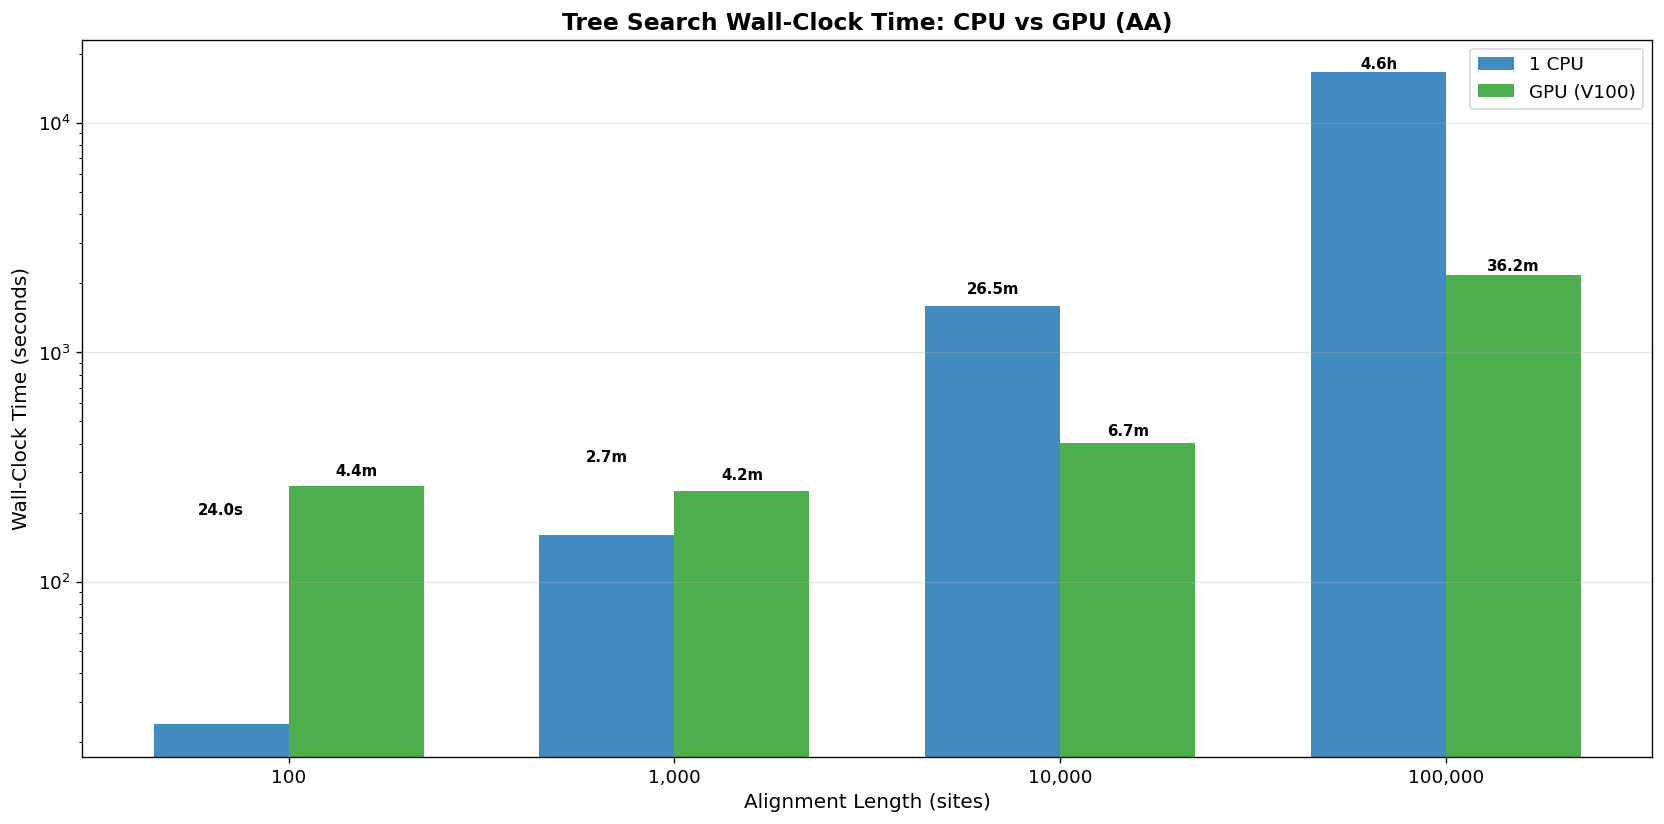

In [19]:
# Wall-clock time bar chart (AA)
fig, ax = plt.subplots(figsize=(14, 7))

available_wfs_aa = [c for c in wf_order if c in time_pivot_aa.columns]
valid_lengths_aa = time_pivot_aa.dropna(thresh=1).index
x = np.arange(len(valid_lengths_aa))
width = 0.35
n_wf = len(available_wfs_aa)

for i, wf in enumerate(available_wfs_aa):
    vals = [time_pivot_aa.loc[l, wf] if l in time_pivot_aa.index and pd.notna(time_pivot_aa.loc[l, wf]) else 0 
            for l in valid_lengths_aa]
    offset = (i - (n_wf-1)/2) * width
    bars = ax.bar(x + offset, vals, width, label=wf, color=wf_colors.get(wf, None), alpha=0.85)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                    fmt_time(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{l:,}' for l in valid_lengths_aa], fontsize=11)
ax.set_xlabel('Alignment Length (sites)', fontsize=12)
ax.set_ylabel('Wall-Clock Time (seconds)', fontsize=12)
ax.set_title('Tree Search Wall-Clock Time: CPU vs GPU (AA)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_comparison_AA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Speedup Analysis (AA)

In [20]:
if '1 CPU' in time_pivot_aa.columns and 'GPU (V100)' in time_pivot_aa.columns:
    speedup_aa = time_pivot_aa['1 CPU'] / time_pivot_aa['GPU (V100)']
    speedup_aa_df = pd.DataFrame({'Speedup (CPU/GPU)': speedup_aa})
    print('GPU Speedup over 1 CPU (AA):')
    print(speedup_aa_df.to_string(float_format='%.2f'))
    
    # Tree-search-only speedup
    ts_pivot_aa = df_aa.pivot_table(index='length', columns='workflow_label', values='tree_search_wall_sec', aggfunc='first')
    if '1 CPU' in ts_pivot_aa.columns and 'GPU (V100)' in ts_pivot_aa.columns:
        ts_speedup_aa = ts_pivot_aa['1 CPU'] / ts_pivot_aa['GPU (V100)']
        speedup_aa_df['Tree Search Speedup'] = ts_speedup_aa
        print()
        print('Tree-search-only speedup (AA):')
        print(speedup_aa_df[['Tree Search Speedup']].to_string(float_format='%.2f'))

GPU Speedup over 1 CPU (AA):
        Speedup (CPU/GPU)
length                   
100                  0.09
1000                 0.64
10000                3.96
100000               7.65

Tree-search-only speedup (AA):
        Tree Search Speedup
length                     
100                    0.09
1000                   0.64
10000                  3.95
100000                 7.64


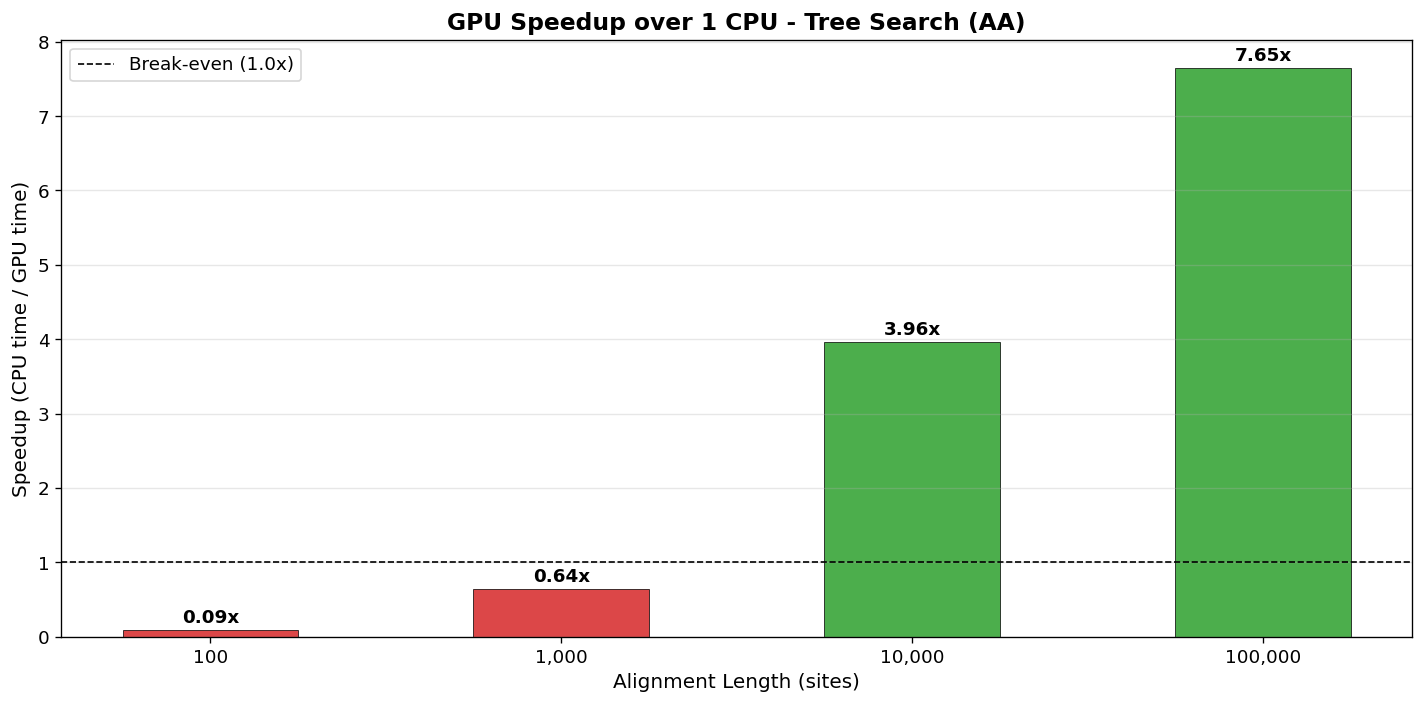

In [21]:
# Speedup bar chart (AA)
if '1 CPU' in time_pivot_aa.columns and 'GPU (V100)' in time_pivot_aa.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    valid = speedup_aa.dropna()
    x = np.arange(len(valid))
    colors = ['#2ca02c' if v >= 1.0 else '#d62728' for v in valid.values]
    
    bars = ax.bar(x, valid.values, 0.5, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Break-even (1.0x)')
    
    for bar, val in zip(bars, valid.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}x', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in valid.index], fontsize=11)
    ax.set_xlabel('Alignment Length (sites)', fontsize=12)
    ax.set_ylabel('Speedup (CPU time / GPU time)', fontsize=12)
    ax.set_title('GPU Speedup over 1 CPU - Tree Search (AA)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'speedup_AA.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 14. Time Breakdown: Initial Trees vs NNI Search (AA)

Initial tree evaluation time (seconds) - AA:
workflow_label  1 CPU  GPU (V100)
length                           
100               1.1        11.3
1000              8.7        12.7
10000            86.1        18.3
100000          970.0        86.8

Tree search time (seconds) - AA:
workflow_label   1 CPU  GPU (V100)
length                            
100               23.4       260.1
1000             158.3       248.8
10000           1578.8       399.3
100000         16511.1      2160.1


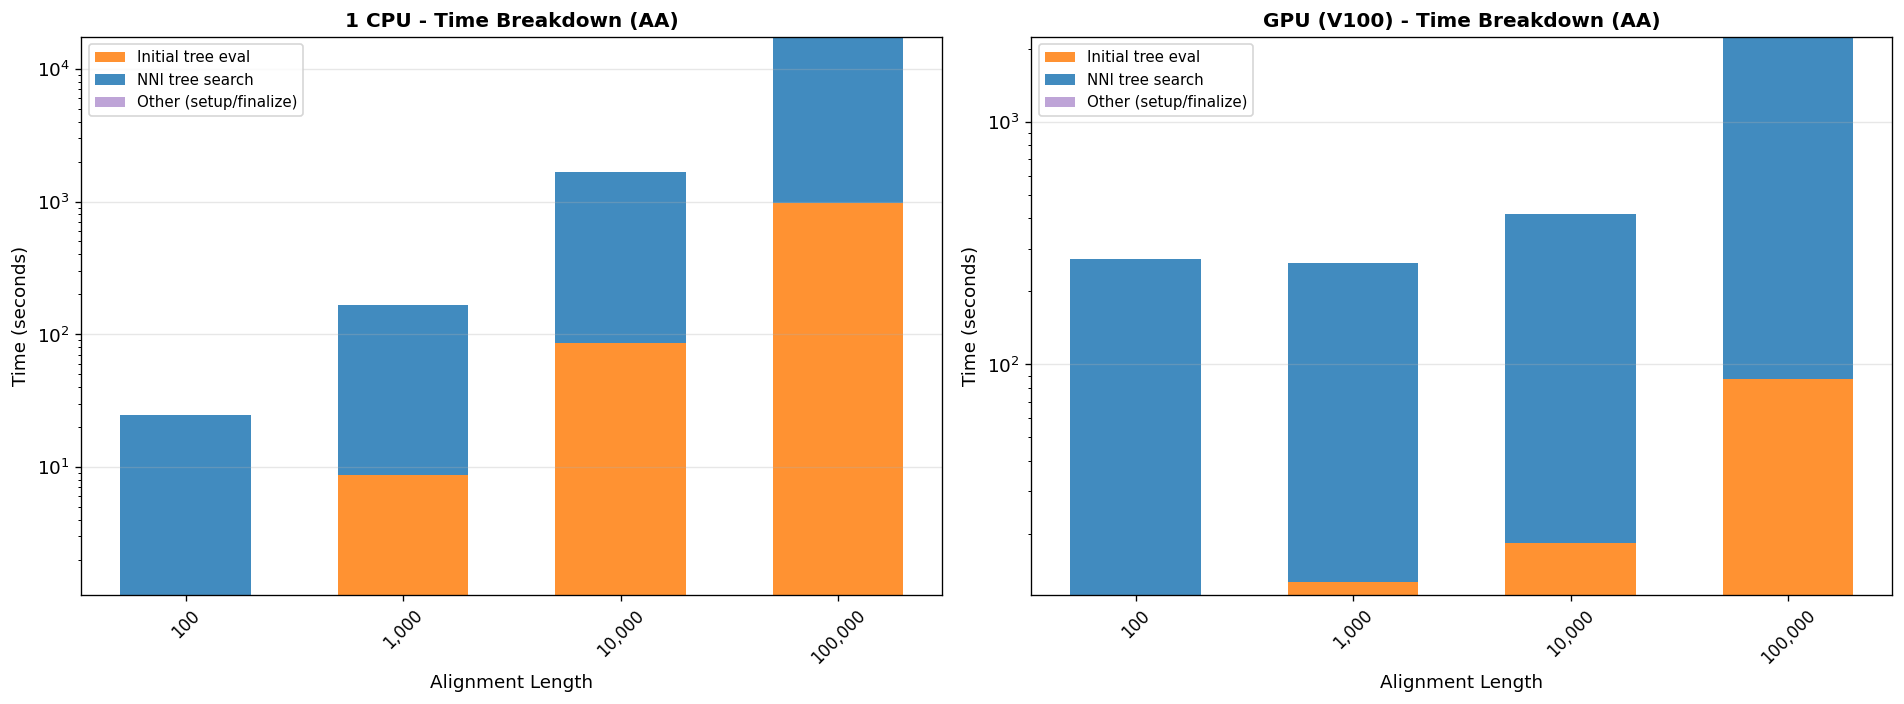

In [22]:
df = df_aa.copy()

init_pivot_aa = df.pivot_table(index='length', columns='workflow_label', values='initial_trees_sec', aggfunc='first')
init_pivot_aa = init_pivot_aa[[c for c in wf_order if c in init_pivot_aa.columns]]

ts_pivot_aa2 = df.pivot_table(index='length', columns='workflow_label', values='tree_search_wall_sec', aggfunc='first')
ts_pivot_aa2 = ts_pivot_aa2[[c for c in wf_order if c in ts_pivot_aa2.columns]]

print('Initial tree evaluation time (seconds) - AA:')
print(init_pivot_aa.to_string(float_format='%.1f'))
print()
print('Tree search time (seconds) - AA:')
print(ts_pivot_aa2.to_string(float_format='%.1f'))

# Stacked bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, wf in enumerate(available_wfs_aa):
    if wf not in init_pivot_aa.columns or wf not in ts_pivot_aa2.columns:
        continue
    ax = axes[idx]
    lengths = init_pivot_aa.index
    init_vals = [init_pivot_aa.loc[l, wf] if pd.notna(init_pivot_aa.loc[l, wf]) else 0 for l in lengths]
    ts_vals = [ts_pivot_aa2.loc[l, wf] if pd.notna(ts_pivot_aa2.loc[l, wf]) else 0 for l in lengths]
    total_vals = [time_pivot_aa.loc[l, wf] if pd.notna(time_pivot_aa.loc[l, wf]) else 0 for l in lengths]
    other_vals = [max(0, t - i - s) for t, i, s in zip(total_vals, init_vals, ts_vals)]
    
    x = np.arange(len(lengths))
    ax.bar(x, init_vals, 0.6, label='Initial tree eval', color='#ff7f0e', alpha=0.85)
    ax.bar(x, ts_vals, 0.6, bottom=init_vals, label='NNI tree search', color='#1f77b4', alpha=0.85)
    bottom2 = [i + s for i, s in zip(init_vals, ts_vals)]
    ax.bar(x, other_vals, 0.6, bottom=bottom2, label='Other (setup/finalize)', color='#9467bd', alpha=0.6)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in lengths], fontsize=10, rotation=45)
    ax.set_xlabel('Alignment Length', fontsize=11)
    ax.set_ylabel('Time (seconds)', fontsize=11)
    ax.set_title(f'{wf} - Time Breakdown (AA)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'time_breakdown_AA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Summary: GPU vs CPU (AA)

In [23]:
if '1 CPU' in time_pivot_aa.columns and 'GPU (V100)' in time_pivot_aa.columns:
    summary_rows_aa = []
    for length in time_pivot_aa.index:
        cpu_time = time_pivot_aa.loc[length, '1 CPU']
        gpu_time = time_pivot_aa.loc[length, 'GPU (V100)']
        cpu_lnl = lnl_pivot_aa.loc[length, '1 CPU'] if length in lnl_pivot_aa.index else None
        gpu_lnl = lnl_pivot_aa.loc[length, 'GPU (V100)'] if length in lnl_pivot_aa.index else None
        
        row = {
            'Length': f'{length:,}',
            'CPU Time': fmt_time(cpu_time),
            'GPU Time': fmt_time(gpu_time),
            'Speedup': f'{cpu_time/gpu_time:.2f}x' if pd.notna(cpu_time) and pd.notna(gpu_time) and gpu_time > 0 else 'N/A',
            'CPU lnL': f'{cpu_lnl:,.4f}' if pd.notna(cpu_lnl) else 'N/A',
            'GPU lnL': f'{gpu_lnl:,.4f}' if pd.notna(gpu_lnl) else 'N/A',
            '|lnL Diff|': f'{abs(cpu_lnl - gpu_lnl):.6f}' if pd.notna(cpu_lnl) and pd.notna(gpu_lnl) else 'N/A',
        }
        summary_rows_aa.append(row)
    
    summary_df_aa = pd.DataFrame(summary_rows_aa)
    print('=== AA Tree Search Summary: GPU vs 1 CPU ===')
    print(summary_df_aa.to_string(index=False))

=== AA Tree Search Summary: GPU vs 1 CPU ===
 Length CPU Time GPU Time Speedup         CPU lnL         GPU lnL |lnL Diff|
    100    24.0s     4.4m   0.09x     -8,152.4255     -8,152.4255   0.000000
  1,000     2.7m     4.2m   0.64x    -82,228.9392    -82,228.9392   0.000000
 10,000    26.5m     6.7m   3.96x   -854,126.3618   -854,126.3618   0.000000
100,000     4.6h    36.2m   7.65x -7,964,675.1129 -7,964,675.1129   0.000000


---
# Part 3: Combined DNA + AA Comparison

## 16. Side-by-Side Wall-Clock Time (DNA vs AA)

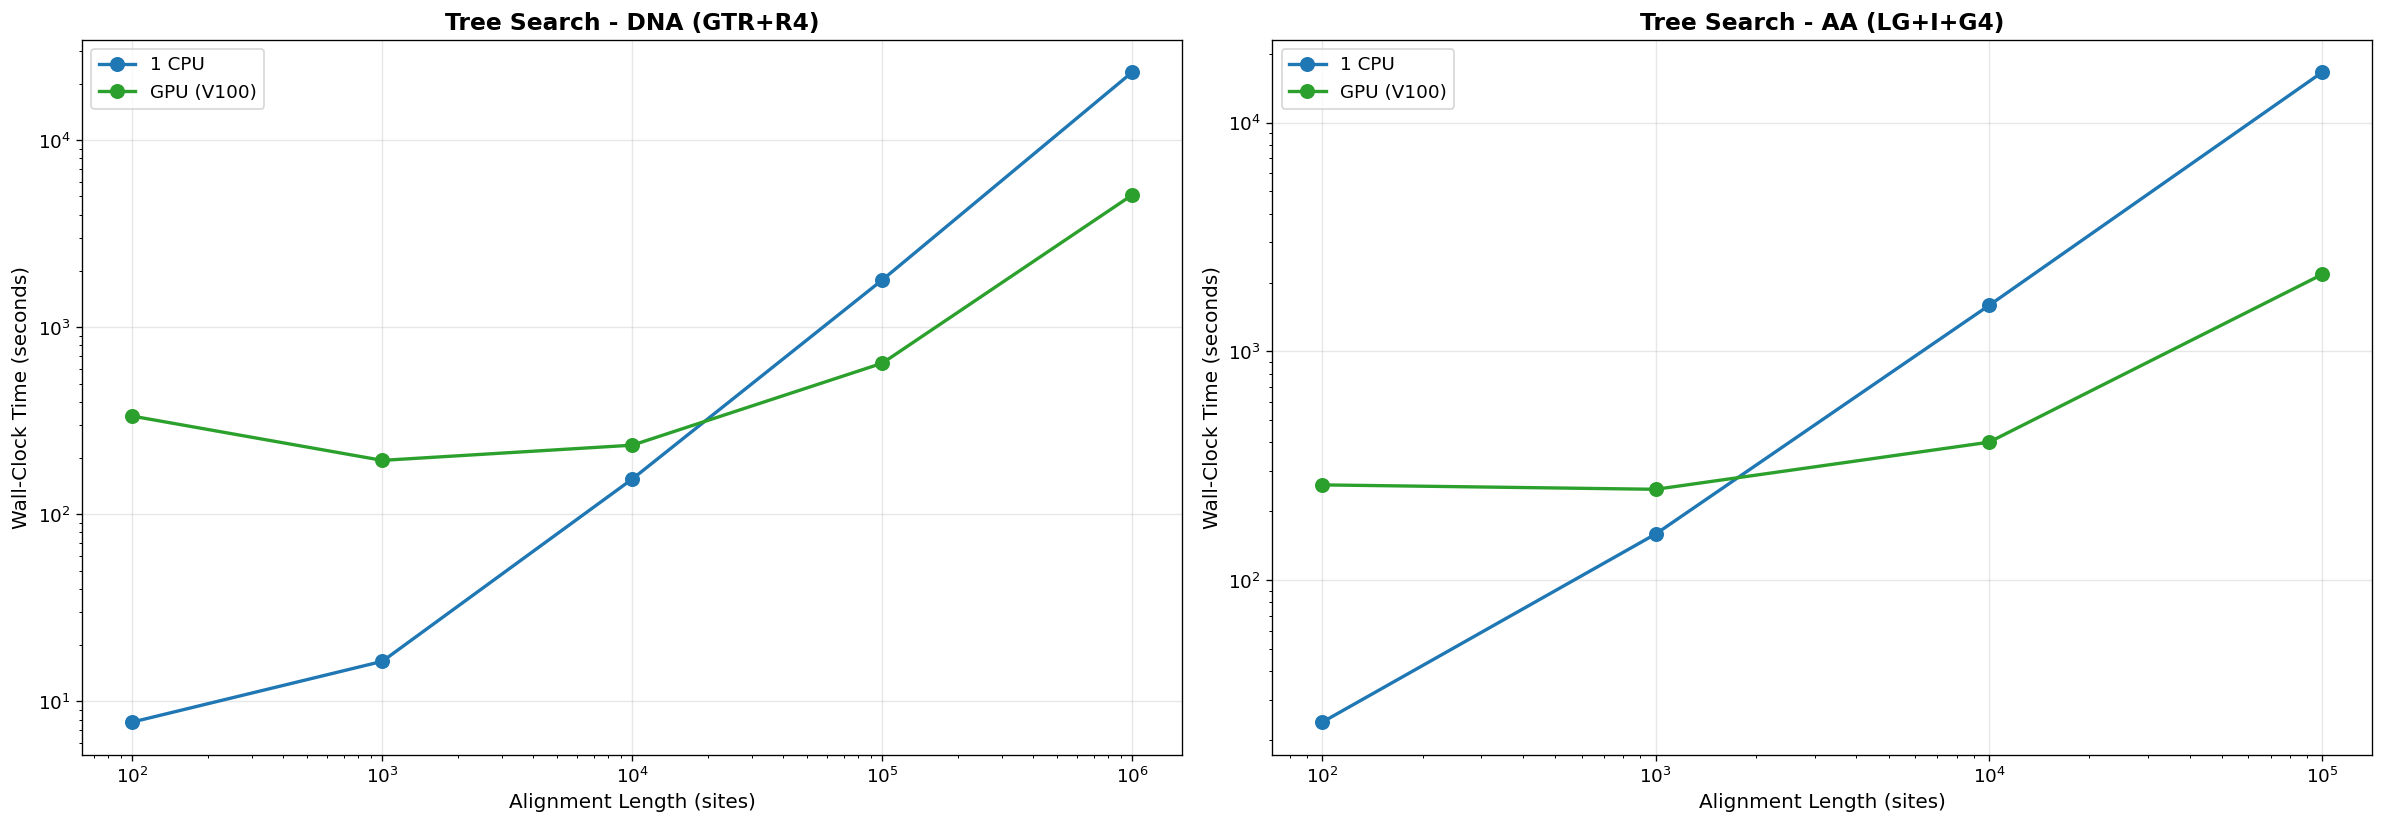

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# DNA
for wf in [c for c in wf_order if c in time_pivot_dna.columns]:
    vals = time_pivot_dna[wf].dropna()
    ax1.plot(vals.index, vals.values, 'o-', label=wf, color=wf_colors.get(wf), linewidth=2, markersize=8)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Alignment Length (sites)', fontsize=12)
ax1.set_ylabel('Wall-Clock Time (seconds)', fontsize=12)
ax1.set_title('Tree Search - DNA (GTR+R4)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# AA
for wf in [c for c in wf_order if c in time_pivot_aa.columns]:
    vals = time_pivot_aa[wf].dropna()
    ax2.plot(vals.index, vals.values, 'o-', label=wf, color=wf_colors.get(wf), linewidth=2, markersize=8)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Alignment Length (sites)', fontsize=12)
ax2.set_ylabel('Wall-Clock Time (seconds)', fontsize=12)
ax2.set_title('Tree Search - AA (LG+I+G4)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_combined.png'), dpi=150, bbox_inches='tight')
plt.show()

## 17. Side-by-Side Speedup (DNA vs AA)

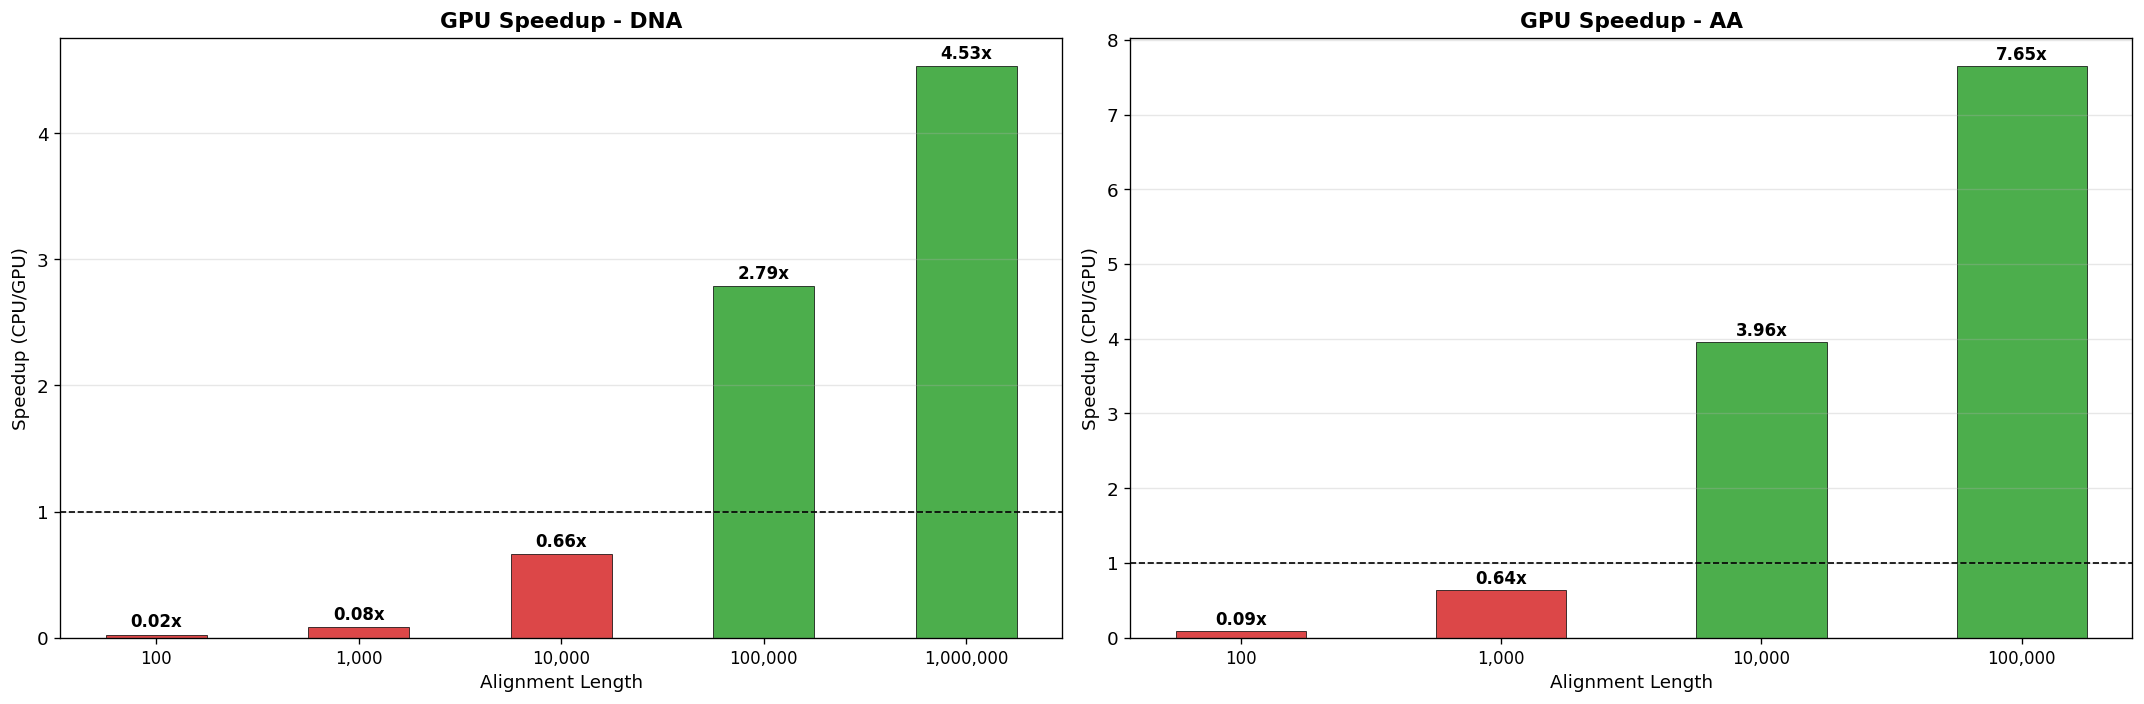

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# DNA speedup
if '1 CPU' in time_pivot_dna.columns and 'GPU (V100)' in time_pivot_dna.columns:
    sp = (time_pivot_dna['1 CPU'] / time_pivot_dna['GPU (V100)']).dropna()
    x = np.arange(len(sp))
    colors = ['#2ca02c' if v >= 1.0 else '#d62728' for v in sp.values]
    bars = ax1.bar(x, sp.values, 0.5, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax1.axhline(y=1.0, color='black', linestyle='--', linewidth=1)
    for bar, val in zip(bars, sp.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'{l:,}' for l in sp.index], fontsize=10)
    ax1.set_xlabel('Alignment Length', fontsize=11)
    ax1.set_ylabel('Speedup (CPU/GPU)', fontsize=11)
    ax1.set_title('GPU Speedup - DNA', fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

# AA speedup
if '1 CPU' in time_pivot_aa.columns and 'GPU (V100)' in time_pivot_aa.columns:
    sp = (time_pivot_aa['1 CPU'] / time_pivot_aa['GPU (V100)']).dropna()
    x = np.arange(len(sp))
    colors = ['#2ca02c' if v >= 1.0 else '#d62728' for v in sp.values]
    bars = ax2.bar(x, sp.values, 0.5, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax2.axhline(y=1.0, color='black', linestyle='--', linewidth=1)
    for bar, val in zip(bars, sp.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'{l:,}' for l in sp.index], fontsize=10)
    ax2.set_xlabel('Alignment Length', fontsize=11)
    ax2.set_ylabel('Speedup (CPU/GPU)', fontsize=11)
    ax2.set_title('GPU Speedup - AA', fontsize=13, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'speedup_combined.png'), dpi=150, bbox_inches='tight')
plt.show()

## 18. Combined Summary Table

In [26]:
summary_all = []
for dtype, df_sub in [('DNA', df_dna), ('AA', df_aa)]:
    tp = df_sub.pivot_table(index='length', columns='workflow_label', values='wall_time_sec', aggfunc='first')
    lp = df_sub.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
    np_pivot = df_sub.pivot_table(index='length', columns='workflow_label', values='nni_iterations', aggfunc='first')
    
    for length in sorted(df_sub['length'].unique()):
        cpu_t = tp.loc[length, '1 CPU'] if length in tp.index and '1 CPU' in tp.columns else None
        gpu_t = tp.loc[length, 'GPU (V100)'] if length in tp.index and 'GPU (V100)' in tp.columns else None
        cpu_lnl = lp.loc[length, '1 CPU'] if length in lp.index and '1 CPU' in lp.columns else None
        gpu_lnl = lp.loc[length, 'GPU (V100)'] if length in lp.index and 'GPU (V100)' in lp.columns else None
        cpu_nni = np_pivot.loc[length, '1 CPU'] if length in np_pivot.index and '1 CPU' in np_pivot.columns else None
        gpu_nni = np_pivot.loc[length, 'GPU (V100)'] if length in np_pivot.index and 'GPU (V100)' in np_pivot.columns else None
        
        summary_all.append({
            'Type': dtype,
            'Length': f'{length:,}',
            'CPU Time': fmt_time(cpu_t) if pd.notna(cpu_t) else 'N/A',
            'GPU Time': fmt_time(gpu_t) if pd.notna(gpu_t) else 'N/A',
            'Speedup': f'{cpu_t/gpu_t:.2f}x' if pd.notna(cpu_t) and pd.notna(gpu_t) and gpu_t > 0 else 'N/A',
            '|lnL Diff|': f'{abs(cpu_lnl - gpu_lnl):.6f}' if pd.notna(cpu_lnl) and pd.notna(gpu_lnl) else 'N/A',
            'NNI Match': 'YES' if pd.notna(cpu_nni) and pd.notna(gpu_nni) and cpu_nni == gpu_nni else ('N/A' if pd.isna(cpu_nni) or pd.isna(gpu_nni) else 'NO'),
        })

summary_all_df = pd.DataFrame(summary_all)
print('=== Combined Tree Search Summary ===')
print(summary_all_df.to_string(index=False))

=== Combined Tree Search Summary ===
Type    Length CPU Time GPU Time Speedup |lnL Diff| NNI Match
 DNA       100     7.8s     5.6m   0.02x   0.207600        NO
 DNA     1,000    16.4s     3.2m   0.08x   0.000000        NO
 DNA    10,000     2.6m     3.9m   0.66x   0.000000       YES
 DNA   100,000    29.8m    10.7m   2.79x   0.000000       YES
 DNA 1,000,000     6.4h     1.4h   4.53x   0.000000       YES
  AA       100    24.0s     4.4m   0.09x   0.000000       YES
  AA     1,000     2.7m     4.2m   0.64x   0.000000       YES
  AA    10,000    26.5m     6.7m   3.96x   0.000000       YES
  AA   100,000     4.6h    36.2m   7.65x   0.000000       YES


## 19. Data Completeness Report

In [27]:
print('Data Completeness (from .iqtree files):')
print()
for dtype in ['DNA', 'AA']:
    print(f'--- {dtype} ---')
    type_dir = os.path.join(RESULTS_DIR, dtype)
    if not os.path.isdir(type_dir):
        print('  Directory not found')
        continue
    for len_dir in sorted(glob.glob(os.path.join(type_dir, 'len_*')),
                          key=lambda x: int(os.path.basename(x).replace('len_', ''))):
        length = int(os.path.basename(len_dir).replace('len_', ''))
        iqtree_files = glob.glob(os.path.join(len_dir, '*.iqtree'))
        log_files = glob.glob(os.path.join(len_dir, '*.log'))
        wfs = []
        for f in iqtree_files:
            if '_OPENACC_' in f:
                wfs.append('OPENACC')
            elif '_VANILA_' in f:
                wfs.append('VANILA')
        
        status = 'COMPLETE' if len(wfs) == 2 else ('PARTIAL' if len(wfs) == 1 else 'MISSING')
        # Check if there are logs without iqtree (incomplete runs)
        if len(log_files) > len(iqtree_files):
            status += ' (some runs incomplete)'
        elif len(iqtree_files) == 0 and len(log_files) > 0:
            status = 'INCOMPLETE (running/timed out)'
        elif len(iqtree_files) == 0 and len(log_files) == 0:
            status = 'EMPTY'
        
        print(f'  len_{length:>10,}: {status} [{"|".join(sorted(wfs))}] ({len(iqtree_files)} .iqtree, {len(log_files)} .log)')
    print()

Data Completeness (from .iqtree files):

--- DNA ---
  len_       100: COMPLETE [OPENACC|VANILA] (2 .iqtree, 2 .log)
  len_     1,000: COMPLETE [OPENACC|VANILA] (2 .iqtree, 2 .log)
  len_    10,000: COMPLETE [OPENACC|VANILA] (2 .iqtree, 2 .log)
  len_   100,000: COMPLETE [OPENACC|VANILA] (2 .iqtree, 2 .log)
  len_ 1,000,000: COMPLETE [OPENACC|VANILA] (2 .iqtree, 2 .log)
  len_10,000,000: EMPTY [] (0 .iqtree, 0 .log)

--- AA ---
  len_       100: COMPLETE [OPENACC|VANILA] (2 .iqtree, 2 .log)
  len_     1,000: COMPLETE [OPENACC|VANILA] (2 .iqtree, 2 .log)
  len_    10,000: COMPLETE [OPENACC|VANILA] (2 .iqtree, 2 .log)
  len_   100,000: COMPLETE [OPENACC|VANILA] (2 .iqtree, 2 .log)
  len_ 1,000,000: MISSING (some runs incomplete) [] (0 .iqtree, 2 .log)
  len_10,000,000: EMPTY [] (0 .iqtree, 0 .log)



## 20. Parsimony Tree Generation Time

In [28]:
# Parsimony tree generation time (CPU-only task, not GPU-accelerated)
for dtype, df_sub in [('DNA', df_dna), ('AA', df_aa)]:
    if 'parsimony_gen_sec' not in df_sub.columns:
        continue
    pars_pivot = df_sub.pivot_table(index='length', columns='workflow_label', values='parsimony_gen_sec', aggfunc='first')
    pars_pivot = pars_pivot[[c for c in wf_order if c in pars_pivot.columns]]
    print(f'Parsimony tree generation time (seconds) - {dtype}:')
    print(pars_pivot.to_string(float_format='%.1f'))
    print()

Parsimony tree generation time (seconds) - DNA:
workflow_label  1 CPU  GPU (V100)
length                           
100               0.5         0.6
1000              1.4         0.8
10000             9.9         5.9
100000          137.3        84.5
1000000        1970.5      1183.7

Parsimony tree generation time (seconds) - AA:
workflow_label  1 CPU  GPU (V100)
length                           
100               1.0         0.9
1000              4.0         2.8
10000            38.5        26.0
100000          521.5       387.4



## 21. Initial Tree Eval Speedup

How much faster is the GPU at evaluating the 98 initial candidate trees?

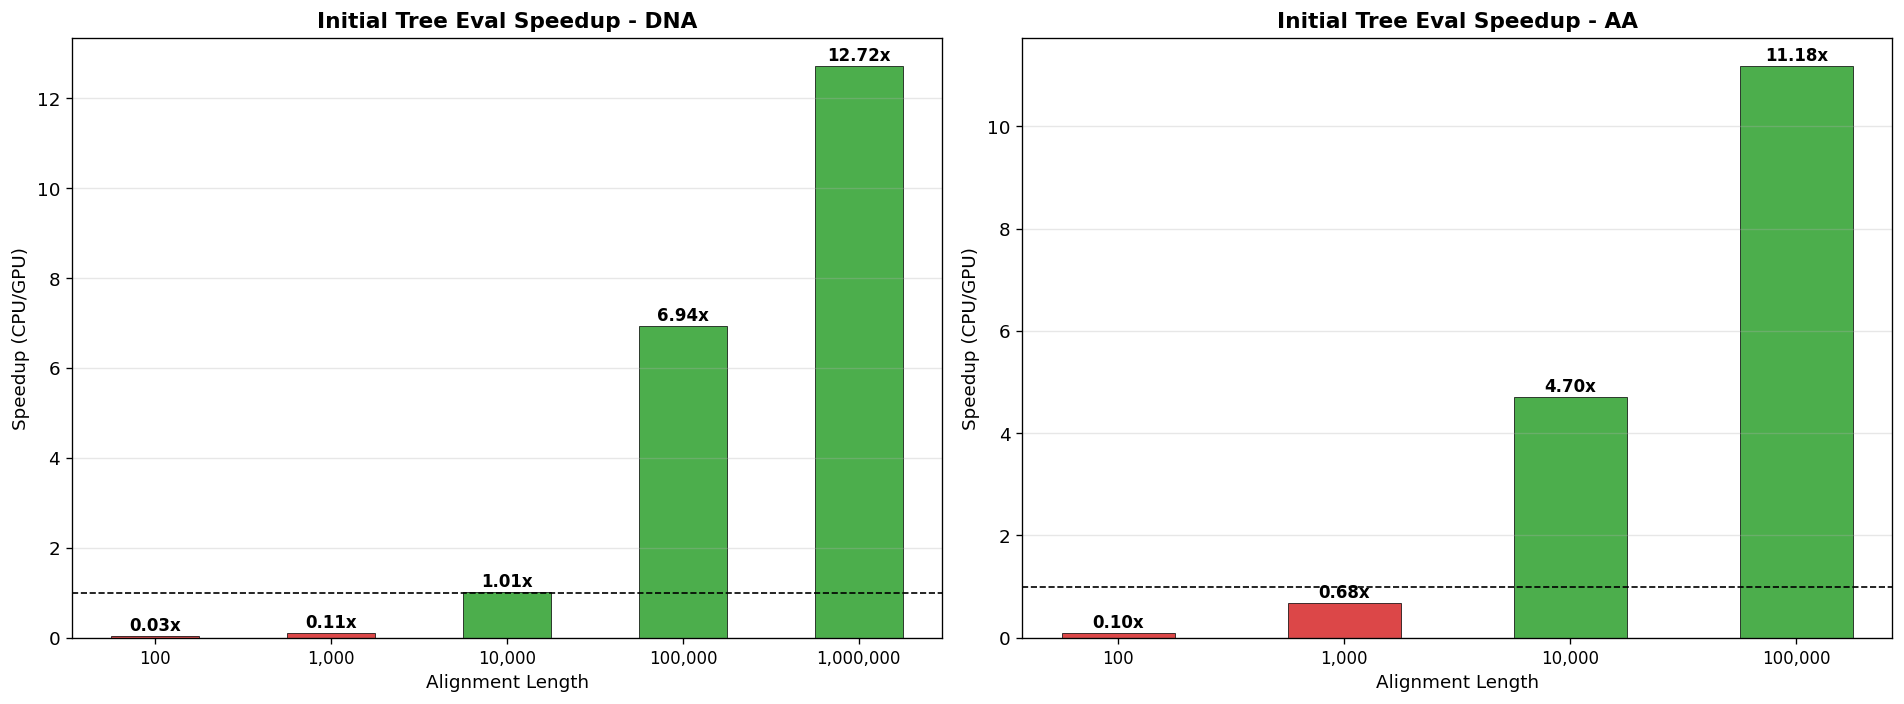

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for idx, (dtype, df_sub, ax) in enumerate([
    ('DNA', df_dna, ax1), ('AA', df_aa, ax2)
]):
    init_p = df_sub.pivot_table(index='length', columns='workflow_label', values='initial_trees_sec', aggfunc='first')
    if '1 CPU' not in init_p.columns or 'GPU (V100)' not in init_p.columns:
        continue
    
    init_speedup = (init_p['1 CPU'] / init_p['GPU (V100)']).dropna()
    x = np.arange(len(init_speedup))
    colors = ['#2ca02c' if v >= 1.0 else '#d62728' for v in init_speedup.values]
    
    bars = ax.bar(x, init_speedup.values, 0.5, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1)
    for bar, val in zip(bars, init_speedup.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in init_speedup.index], fontsize=10)
    ax.set_xlabel('Alignment Length', fontsize=11)
    ax.set_ylabel('Speedup (CPU/GPU)', fontsize=11)
    ax.set_title(f'Initial Tree Eval Speedup - {dtype}', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'initial_tree_speedup.png'), dpi=150, bbox_inches='tight')
plt.show()

---
# Part 4: In-Progress Runs Analysis

The following results come from runs that have not yet completed.  
Only partial metrics (from `.log` files) are available.

In [30]:
if len(df_inprogress) > 0:
    print('=== In-Progress Run Details ===\n')
    for _, r in df_inprogress.iterrows():
        print(f"  {r['data_type']} | Length: {r['length']:,} | {r['workflow_label']}")
        print(f"    Status: IN-PROGRESS (no .iqtree file)")
        if pd.notna(r.get('last_iteration')):
            print(f"    Last iteration: {int(r['last_iteration'])}")
        if pd.notna(r.get('last_lnl')):
            print(f"    Last log-L: {r['last_lnl']:,.4f}")
        if r.get('last_time_str'):
            print(f"    Elapsed: ~{r['last_time_str']}")
        if pd.notna(r.get('initial_trees_sec')):
            print(f"    Initial tree eval: {r['initial_trees_sec']:,.1f}s")
        if pd.notna(r.get('parsimony_gen_sec')):
            print(f"    Parsimony generation: {r['parsimony_gen_sec']:,.1f}s")
        if pd.notna(r.get('n_candidate_trees')):
            print(f"    Candidate trees: {int(r['n_candidate_trees'])}")
        if pd.notna(r.get('best_candidate_score')):
            print(f"    Best candidate score: {r['best_candidate_score']:,.4f}")
        if pd.notna(r.get('candidate_cpu_time')):
            print(f"    CPU time at candidate init: {r['candidate_cpu_time']:,.1f}s")
        print()
else:
    print('No in-progress runs found.')


=== In-Progress Run Details ===

  AA | Length: 1,000,000 | GPU (V100)
    Status: IN-PROGRESS (no .iqtree file)
    Last iteration: 10
    Last log-L: -83,153,182.4420
    Elapsed: ~3h:18m:35s
    Initial tree eval: 739.4s
    Parsimony generation: 9,757.7s

  AA | Length: 1,000,000 | 1 CPU
    Status: IN-PROGRESS (no .iqtree file)
    Last iteration: 90
    Last log-L: -83,153,242.6510
    Elapsed: ~45h:40m:35s (5h:38m:23s left)
    Initial tree eval: 10,271.8s
    Parsimony generation: 12,558.5s
    Candidate trees: 2
    Best candidate score: -83,153,181.6230
    CPU time at candidate init: 49,829.6s



### Initial Tree Evaluation: In-Progress Runs

Even for in-progress runs, we can compare the initial tree evaluation time (GPU vs CPU).

In [31]:
if len(df_inprogress) > 0 and 'initial_trees_sec' in df_inprogress.columns:
    # Combine completed + in-progress for initial tree eval comparison
    df_init_all = pd.concat([df_all[['data_type', 'length', 'workflow_label', 'status', 
                                      'initial_trees_sec', 'parsimony_gen_sec']]])
    
    for dtype in df_init_all['data_type'].unique():
        df_sub = df_init_all[df_init_all['data_type'] == dtype]
        init_p = df_sub.pivot_table(index='length', columns='workflow_label', values='initial_trees_sec', aggfunc='first')
        pars_p = df_sub.pivot_table(index='length', columns='workflow_label', values='parsimony_gen_sec', aggfunc='first')
        
        if '1 CPU' in init_p.columns and 'GPU (V100)' in init_p.columns:
            init_p['Speedup'] = init_p['1 CPU'] / init_p['GPU (V100)']
            print(f'\nInitial tree evaluation time ({dtype}) — all runs (completed + in-progress):')
            print(init_p.to_string(float_format=lambda x: f'{x:,.1f}' if abs(x) > 10 else f'{x:.2f}'))
        
        if not pars_p.empty and '1 CPU' in pars_p.columns and 'GPU (V100)' in pars_p.columns:
            print(f'\nParsimony tree generation time ({dtype}):')
            print(pars_p.to_string(float_format=lambda x: f'{x:,.1f}'))
else:
    print('No in-progress data to analyze.')



Initial tree evaluation time (AA) — all runs (completed + in-progress):
workflow_label    1 CPU  GPU (V100)  Speedup
length                                      
100                1.09        11.3     0.10
1000               8.67        12.7     0.68
10000              86.1        18.3     4.70
100000            970.0        86.8     11.2
1000000        10,271.8       739.4     13.9

Parsimony tree generation time (AA):
workflow_label    1 CPU  GPU (V100)
length                             
100                 1.0         0.9
1000                4.0         2.8
10000              38.5        26.0
100000            521.5       387.4
1000000        12,558.5     9,757.7

Initial tree evaluation time (DNA) — all runs (completed + in-progress):
workflow_label   1 CPU  GPU (V100)  Speedup
length                                     
100               0.28        9.67     0.03
1000              0.92        8.55     0.11
10000             9.83        9.69     1.01
100000           156.1      

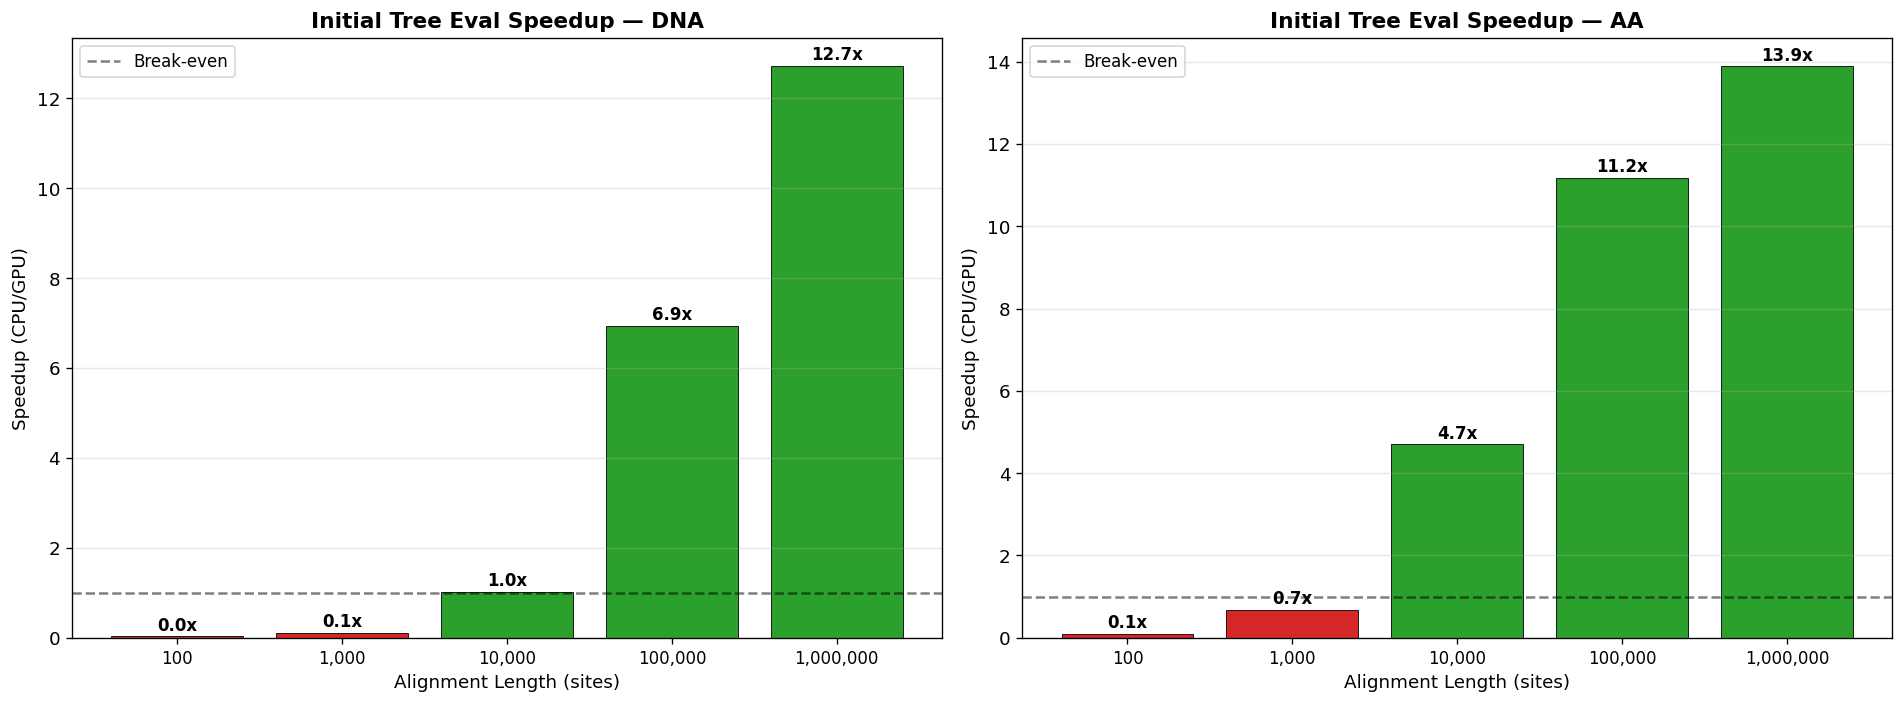

In [32]:
# Updated Initial Tree Eval Speedup plot including AA 1M data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for idx, (dtype, ax) in enumerate([('DNA', ax1), ('AA', ax2)]):
    df_sub = df_all[df_all['data_type'] == dtype]
    init_p = df_sub.pivot_table(index='length', columns='workflow_label', values='initial_trees_sec', aggfunc='first')
    if '1 CPU' not in init_p.columns or 'GPU (V100)' not in init_p.columns:
        ax.text(0.5, 0.5, f'No data for {dtype}', transform=ax.transAxes, ha='center')
        continue
    
    speedup = (init_p['1 CPU'] / init_p['GPU (V100)']).dropna()
    x = np.arange(len(speedup))
    colors = ['#2ca02c' if v >= 1.0 else '#d62728' for v in speedup.values]
    
    bars = ax.bar(x, speedup.values, color=colors, edgecolor='black', linewidth=0.5)
    
    ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Break-even')
    for bar, val in zip(bars, speedup.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in speedup.index], fontsize=10)
    ax.set_xlabel('Alignment Length (sites)', fontsize=11)
    ax.set_ylabel('Speedup (CPU/GPU)', fontsize=11)
    ax.set_title(f'Initial Tree Eval Speedup — {dtype}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'initial_tree_speedup.png'), dpi=150, bbox_inches='tight')
plt.show()
